# Exploratory Data Analysis

Conduct a high level statistical analysis on the continous and categorical variables.

In [38]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Load the data into a pandas DataFrame
df = pd.read_csv('outputs/train_cleaned.csv')

# Display the shape of the data
print(df.shape)

(1460, 81)


## Review the Distribution of the SalesPrice Label

In [40]:
# View the statistical data for the SalePrice column
mean_price = df['SalePrice'].mean().round(2)
median_price = df['SalePrice'].median()
mode_price = df['SalePrice'].mode()[0]
std_price = df['SalePrice'].std().round(3)
min_price = df['SalePrice'].min()
max_price = df['SalePrice'].max()
distribution_price = df['SalePrice'].skew()

# Print the data
print(f'Mean: {mean_price}')
print(f'Median: {median_price}')
print(f'Mode: {mode_price}')
print(f'Standard Deviation: {std_price}')
print(f'Minimum: {min_price}')
print(f'Maximum: {max_price}')
print(f'Distribution: {distribution_price}')


Mean: 180921.2
Median: 163000.0
Mode: 140000
Standard Deviation: 79442.503
Minimum: 34900
Maximum: 755000
Distribution: 1.8828757597682129


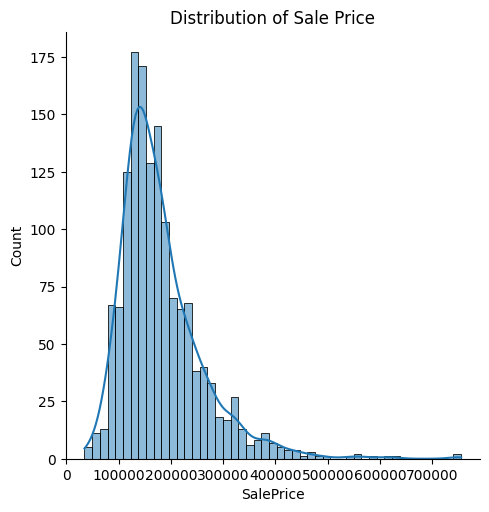

In [42]:
# View the distribution of the data
sns.displot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Price')
plt.show()

In [43]:
# Apply log transformation to the SalePrice column as the SalePrice is highly right-skewed
df['SalePrice_log'] = np.log(df['SalePrice'])


In [44]:
# View the statistical data for the SalePrice_log column
mean_price = df['SalePrice_log'].mean().round(2)
median_price = df['SalePrice_log'].median()
mode_price = df['SalePrice_log'].mode()[0]
std_price = df['SalePrice_log'].std().round(3)
min_price = df['SalePrice_log'].min()
max_price = df['SalePrice_log'].max()
distribution_price = df['SalePrice_log'].skew()

# Print the data
print(f'Mean: {mean_price}')
print(f'Median: {median_price}')
print(f'Mode: {mode_price}')
print(f'Standard Deviation: {std_price}')
print(f'Minimum: {min_price}')
print(f'Maximum: {max_price}')
print(f'Distribution: {distribution_price}')

Mean: 12.02
Median: 12.0015054797889
Mode: 11.84939770159144
Standard Deviation: 0.399
Minimum: 10.460242108190519
Maximum: 13.534473028231162
Distribution: 0.12133506220520406


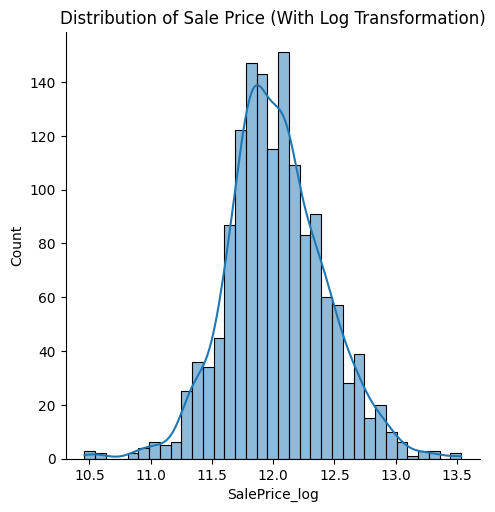

In [45]:
# View the distribution of the data
sns.displot(df['SalePrice_log'], kde=True)
plt.title('Distribution of Sale Price (With Log Transformation)')
plt.show()

## View the statistical data of the continuous data

In [46]:
# Remove the integer columns that are not continuous
statistical_data = df.drop(['Id'], axis=1)  # No inplace=True

# Create a data frame of the statistical data
statistical_data = statistical_data.describe().round(2)

# Export the data to review the output
statistical_data.to_csv('outputs/statistical_data.csv', index=False)


In [47]:
# Create a dataframe for the continuous variables
continuous_data = df.select_dtypes(include='number')

# drop the Id column
continuous_data.drop('Id', axis=1, inplace=True)

# Display the first 5 rows of the continuous data
continuous_data.head()

# Export the continuous data to a csv file
continuous_data.to_csv('outputs/continuous_data.csv', index=False)


### Test the correlation of the data

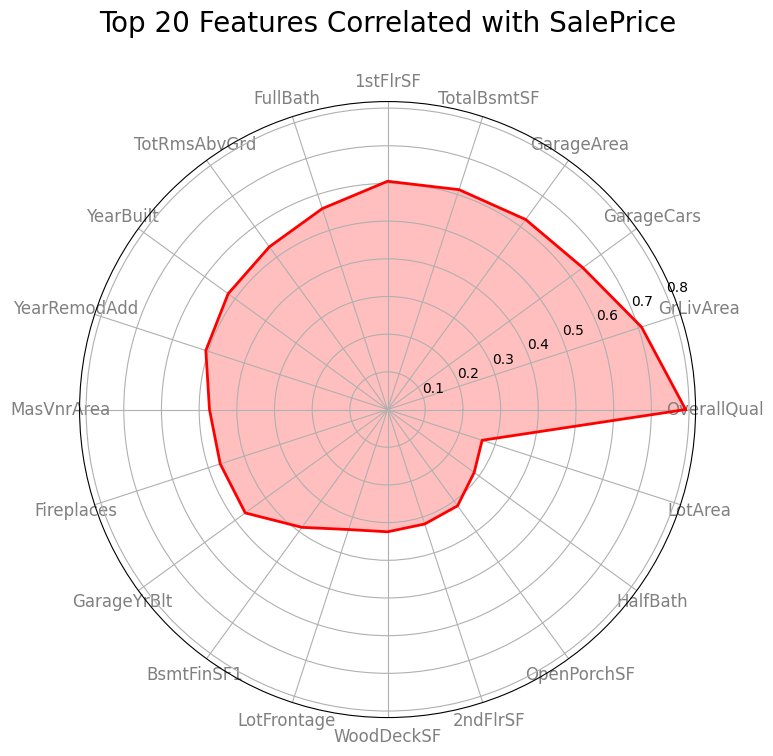

In [51]:
# Compute correlation
correlation_matrix = continuous_data.corr()

# Get correlation of all features with SalesPrice
correlation_with_salesprice = correlation_matrix['SalePrice'].drop(['SalePrice', 'SalePrice_log'])

# Sort correlations in descending order
correlation_ranked = correlation_with_salesprice.abs().sort_values(ascending=False)

# Select the top 20 features
top_20_features = correlation_ranked.head(20)

# Create a radar chart
categories = top_20_features.index
values = top_20_features.values

# Ensure the radar chart is circular
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

plt.title('Top 20 Features Correlated with SalePrice', size=20, color='black', y=1.1)
plt.show()


In [52]:
print(correlation_ranked)

OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
EnclosedPorch    0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass       0.084284
OverallCond      0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold           0.028923
LowQualFinSF     0.025606
MiscVal          0.021190
BsmtHalfBath     0.016844
BsmtFinSF2       0.011378
Name: SalePrice, dtype: float64


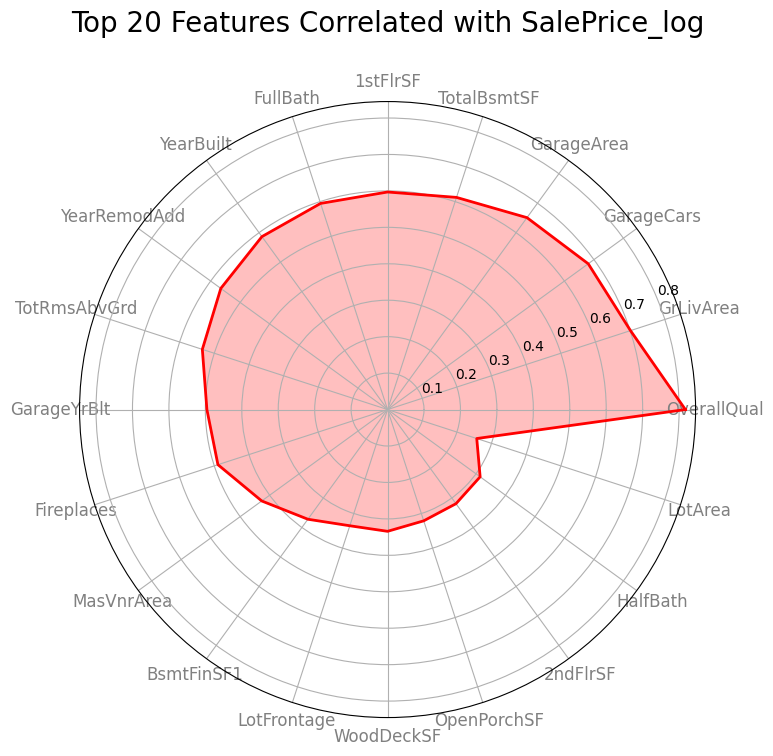

In [53]:
# Compute correlation
correlation_matrix = continuous_data.corr()

# Get correlation of all features with SalesPrice
correlation_with_salesprice = correlation_matrix['SalePrice_log'].drop(['SalePrice', 'SalePrice_log'])

# Sort correlations in descending order
correlation_ranked = correlation_with_salesprice.abs().sort_values(ascending=False)

# Select the top 20 features
top_20_features = correlation_ranked.head(20)

# Create a radar chart
categories = top_20_features.index
values = top_20_features.values

# Ensure the radar chart is circular
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

plt.title('Top 20 Features Correlated with SalePrice_log', size=20, color='black', y=1.1)
plt.show()

In [54]:
# Print the top 20 features correlated with SalePrice_log
print(correlation_ranked)

OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
TotRmsAbvGrd     0.534422
GarageYrBlt      0.495794
Fireplaces       0.489449
MasVnrArea       0.426775
BsmtFinSF1       0.372023
LotFrontage      0.335292
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209044
EnclosedPorch    0.149050
KitchenAbvGr     0.147548
ScreenPorch      0.121208
MSSubClass       0.073959
PoolArea         0.069798
MoSold           0.057329
3SsnPorch        0.054900
LowQualFinSF     0.037963
YrSold           0.037263
OverallCond      0.036868
MiscVal          0.020021
BsmtHalfBath     0.005149
BsmtFinSF2       0.004832
Name: SalePrice_log, dtype: float64


## Review the correlation between the sales price and all other continuous variables in a visual format

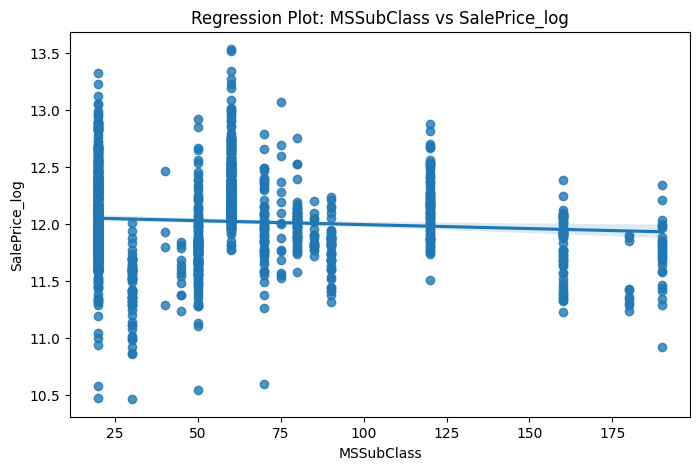

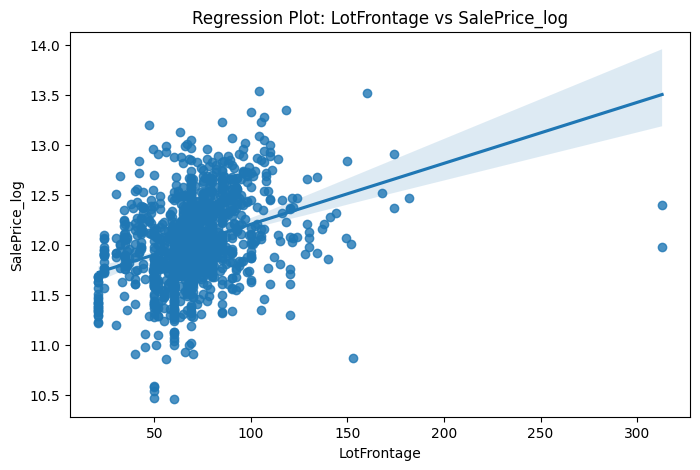

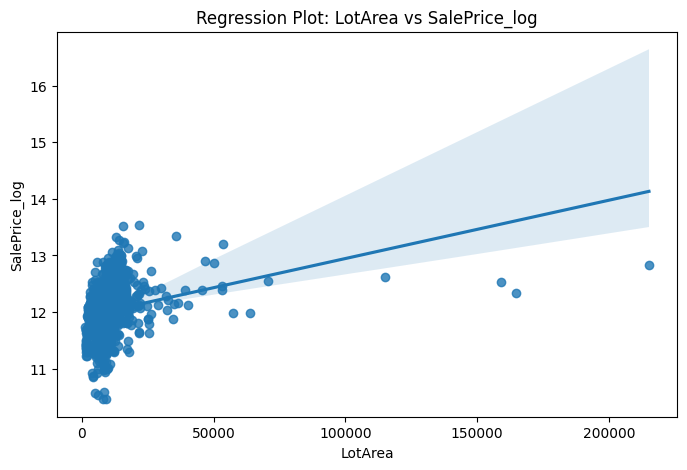

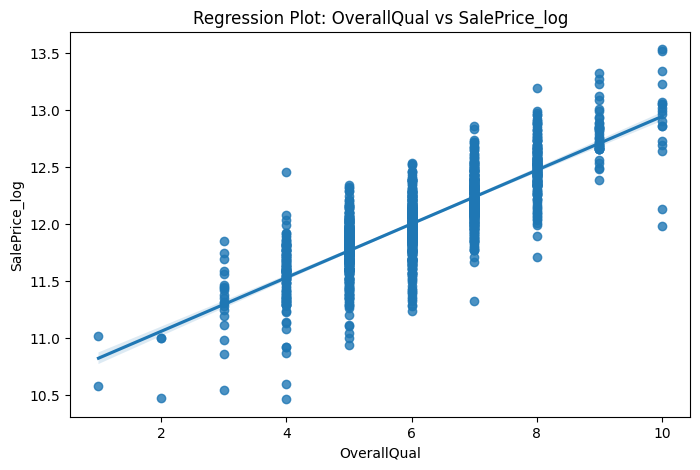

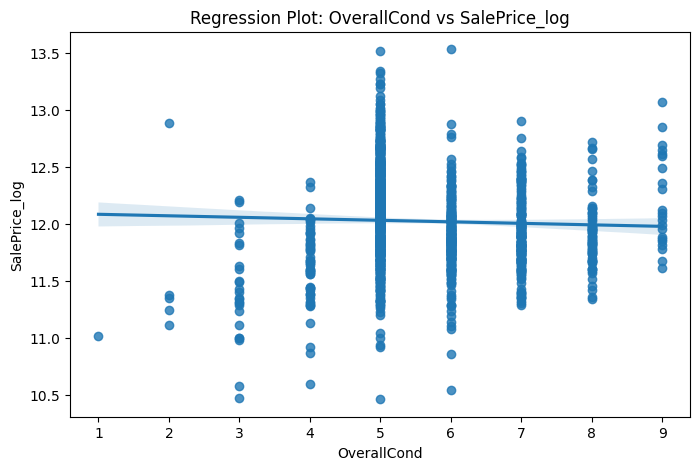

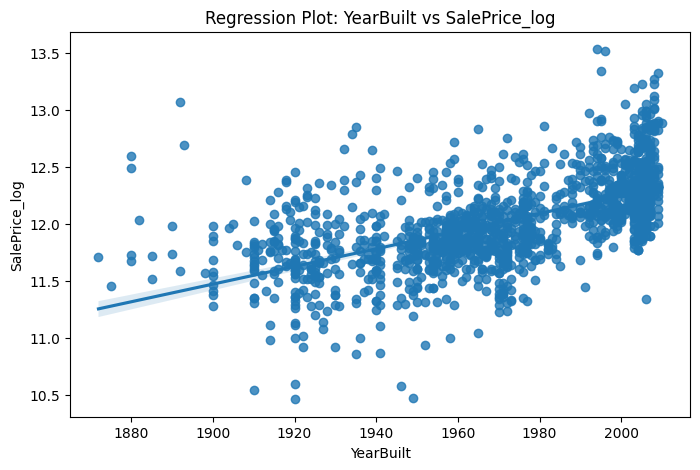

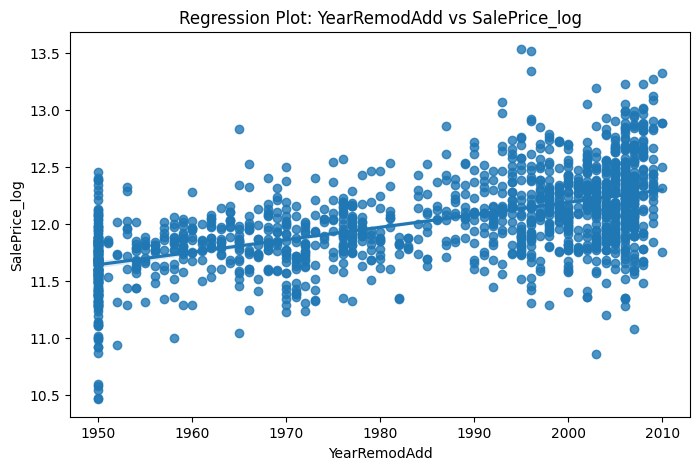

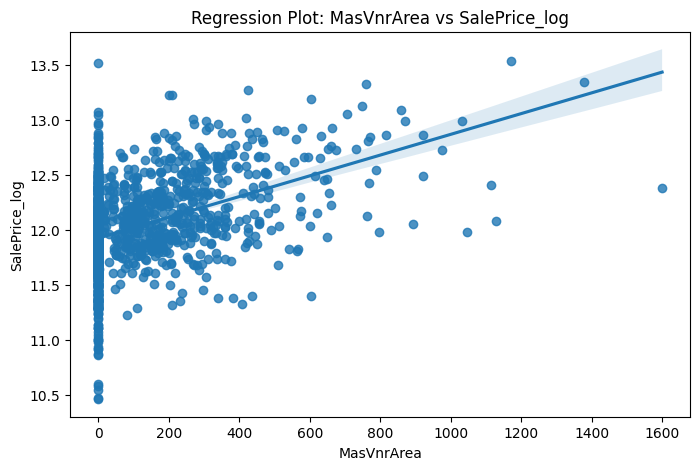

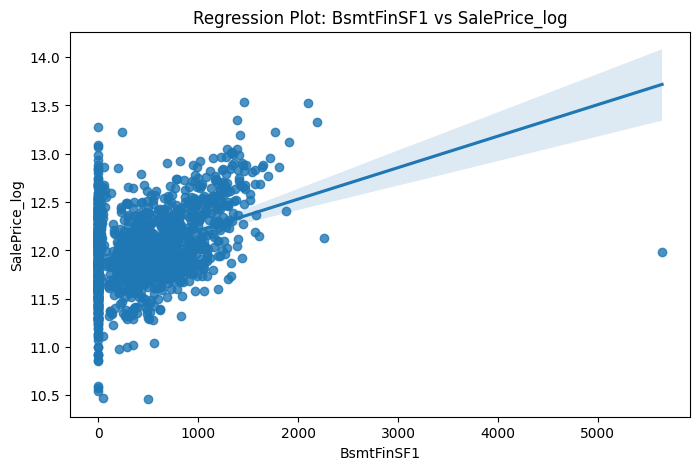

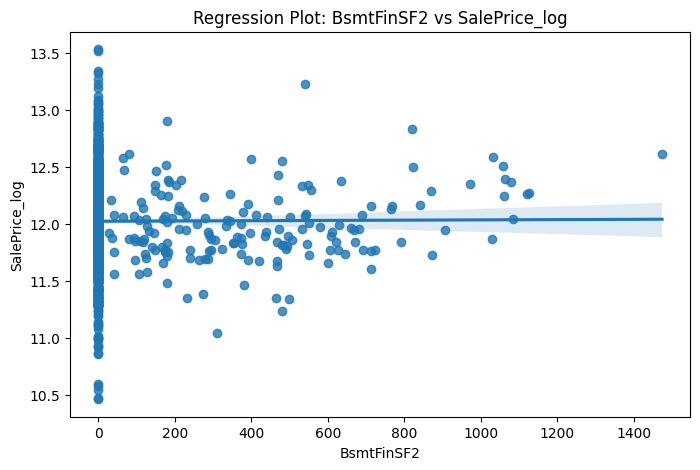

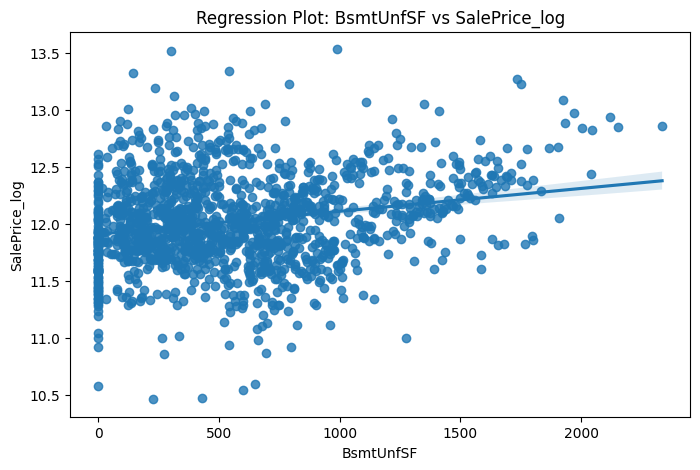

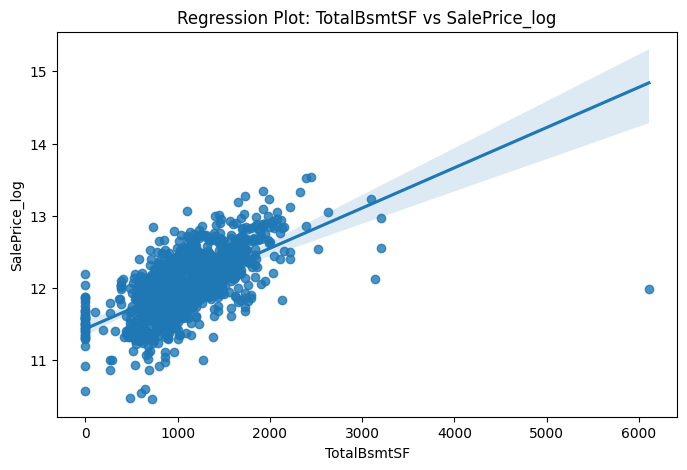

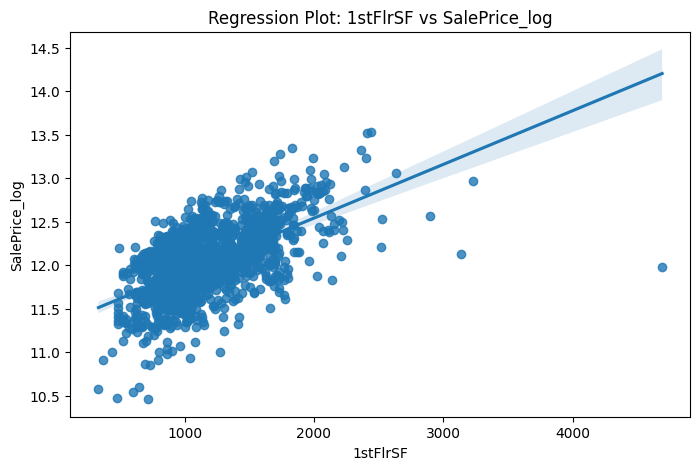

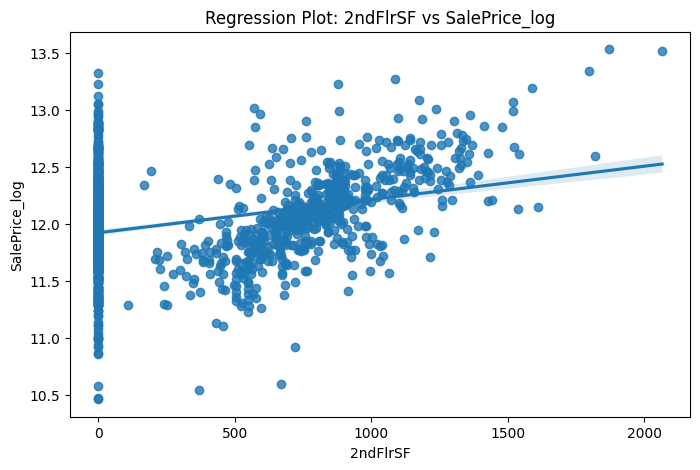

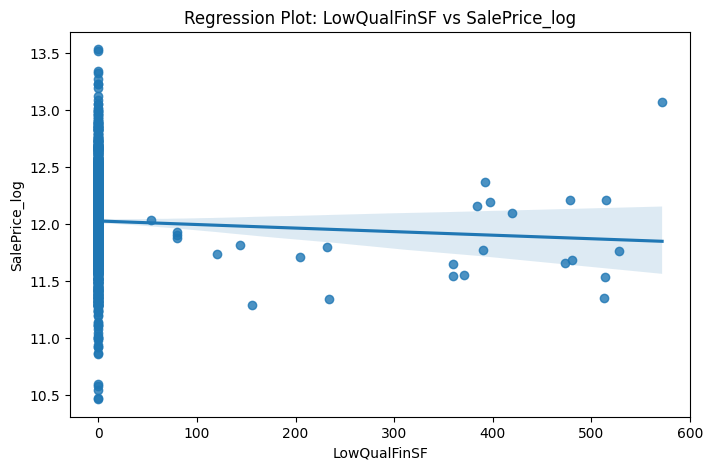

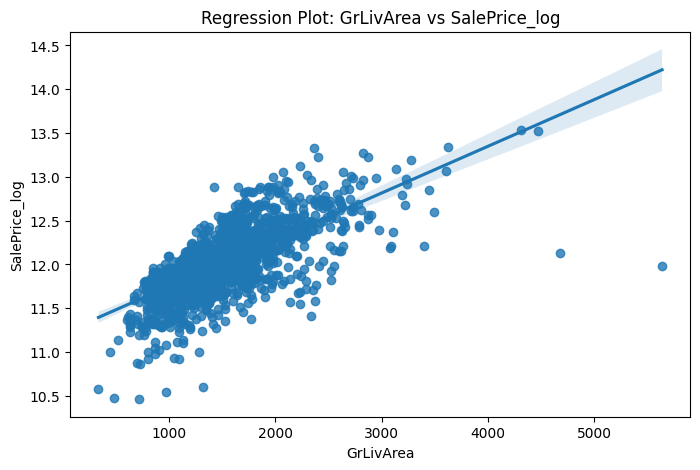

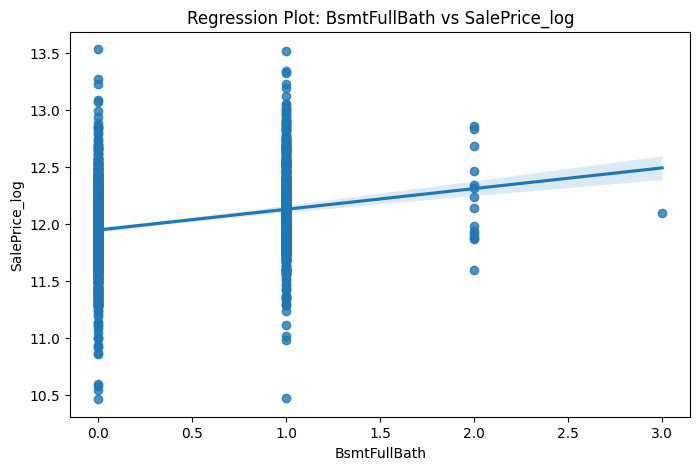

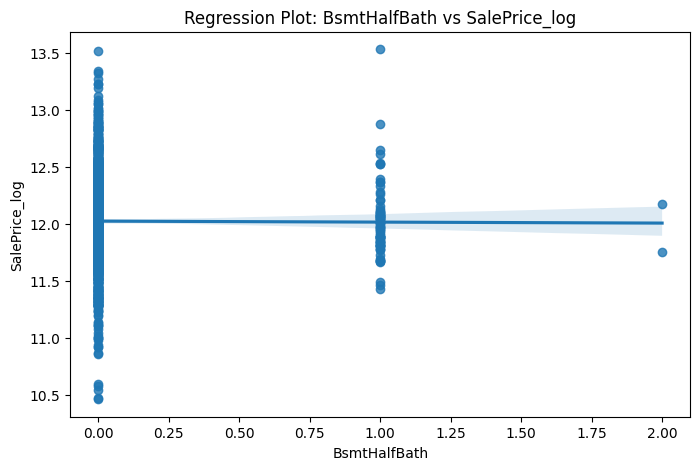

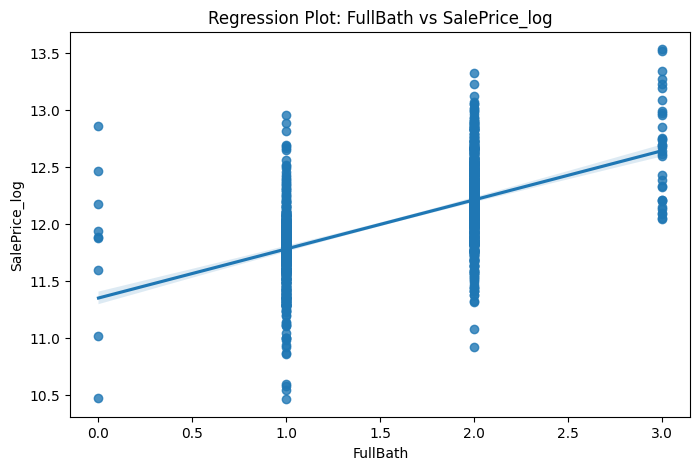

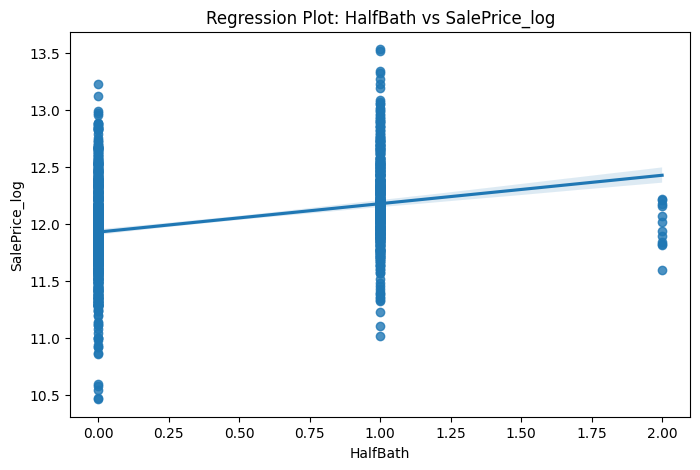

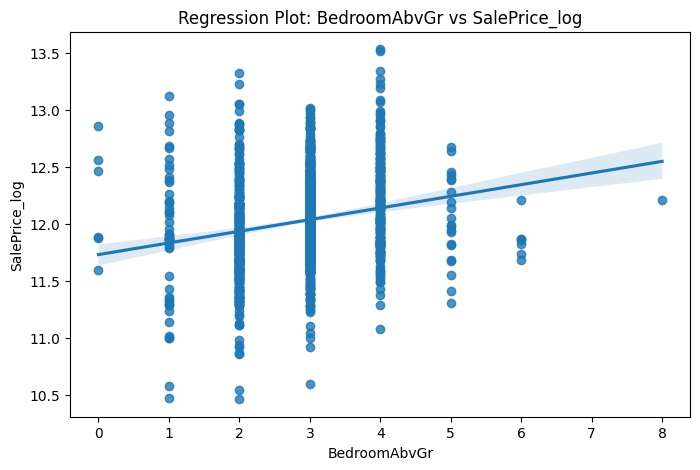

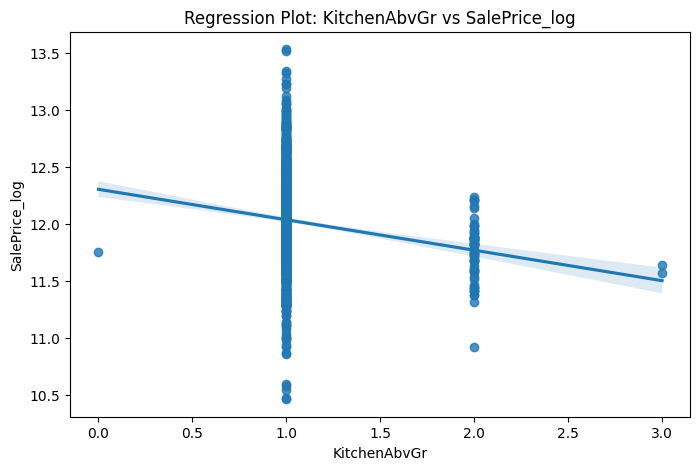

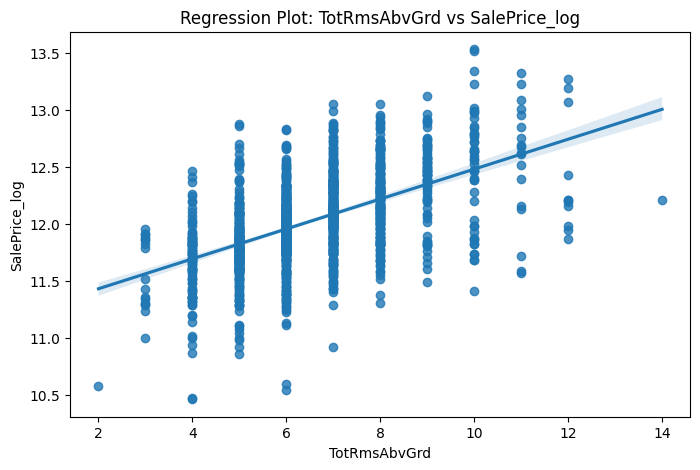

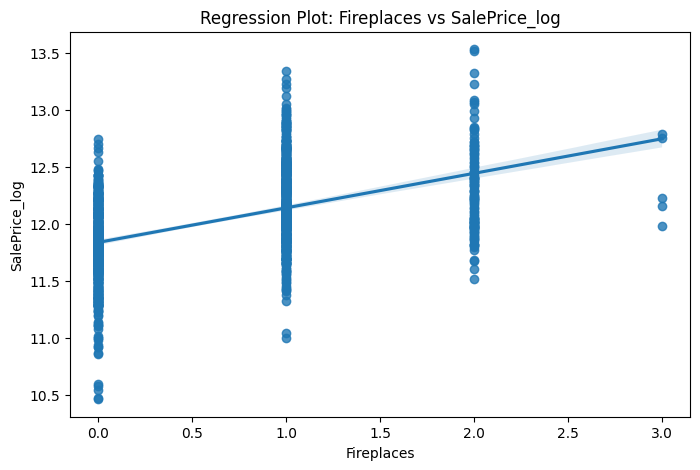

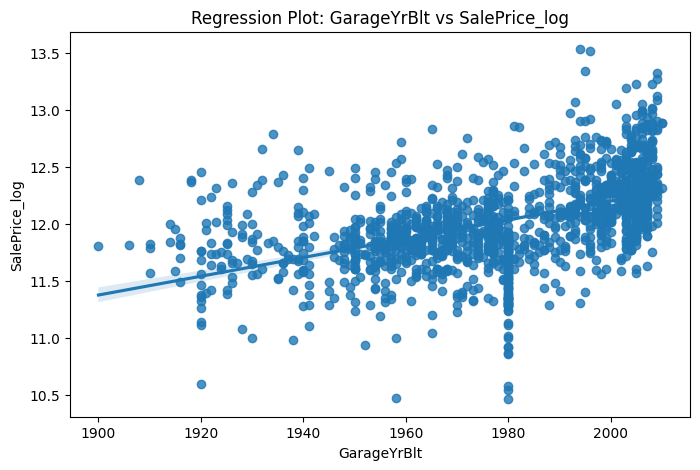

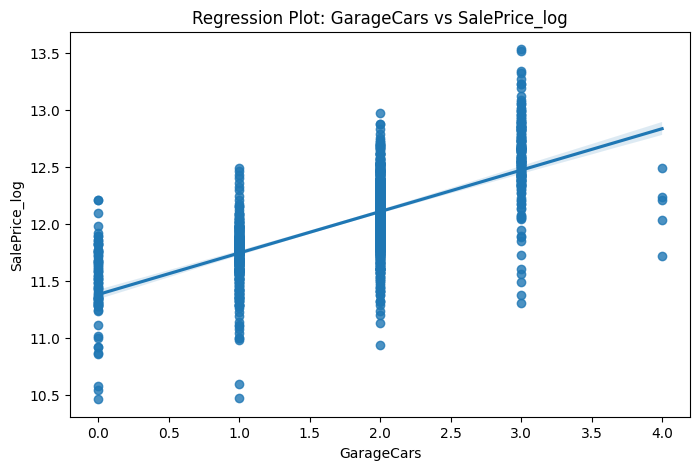

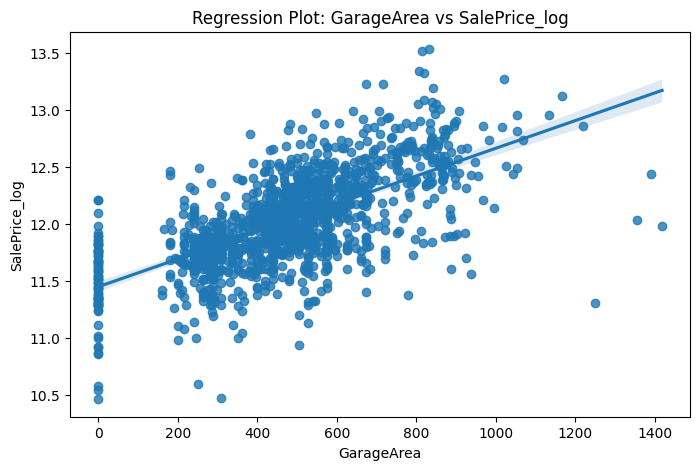

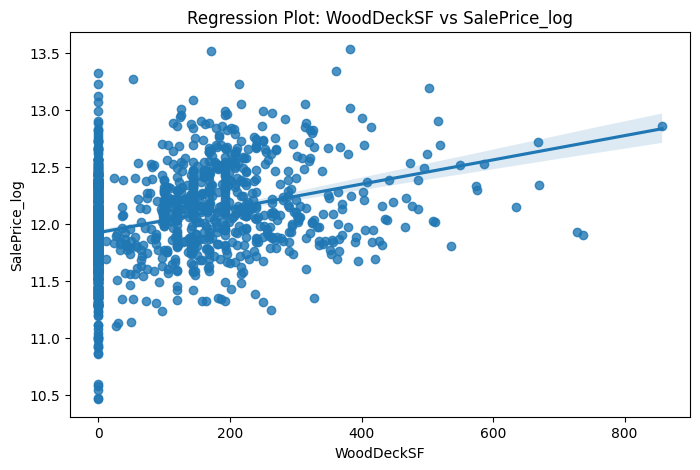

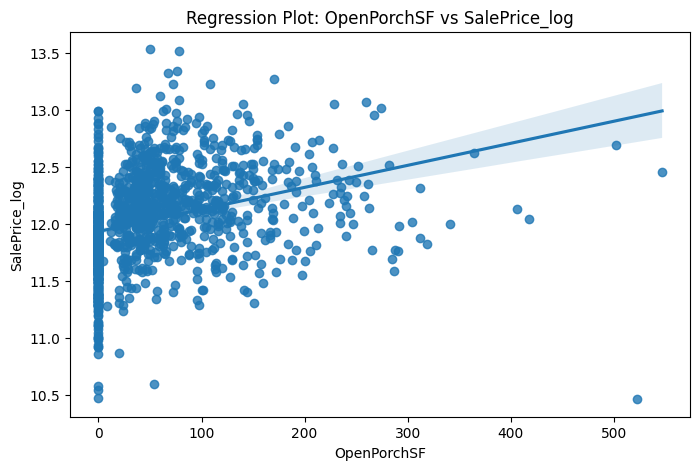

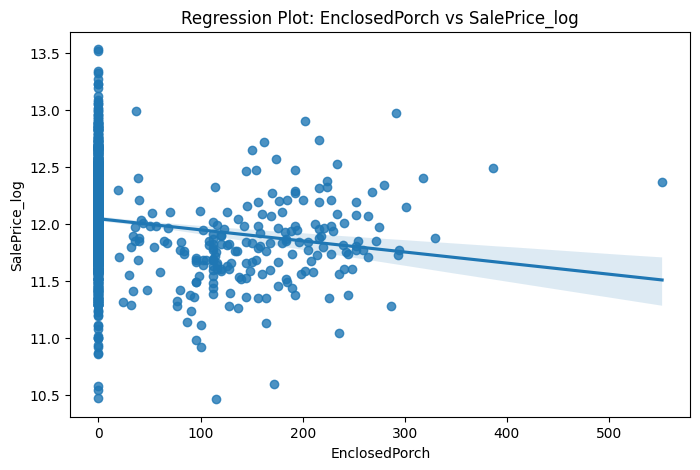

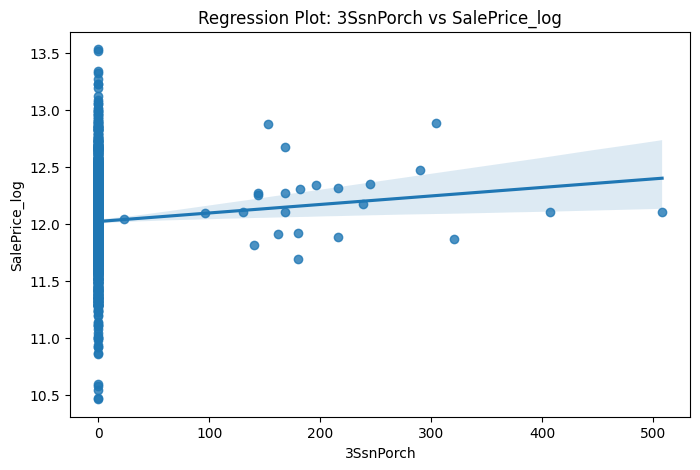

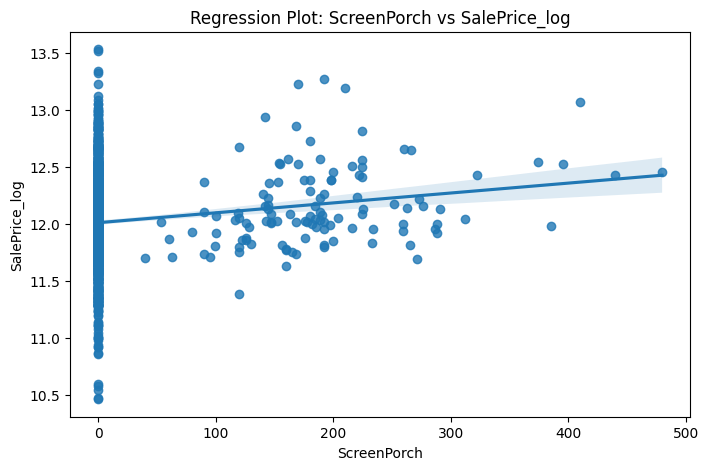

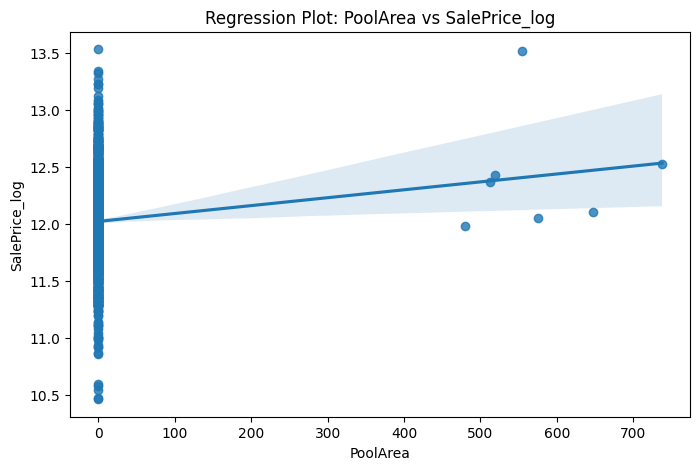

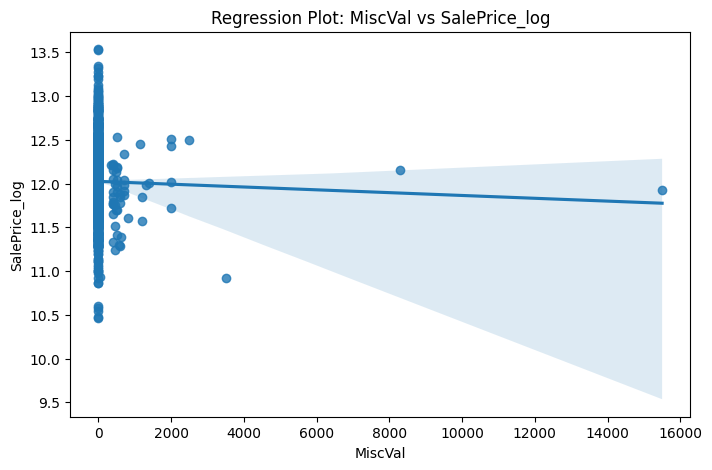

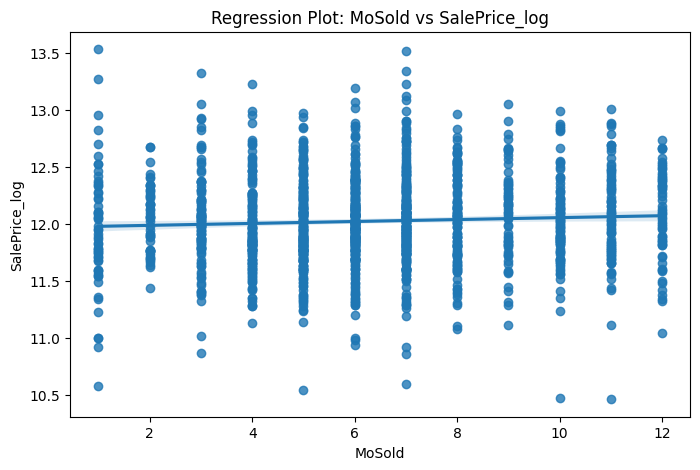

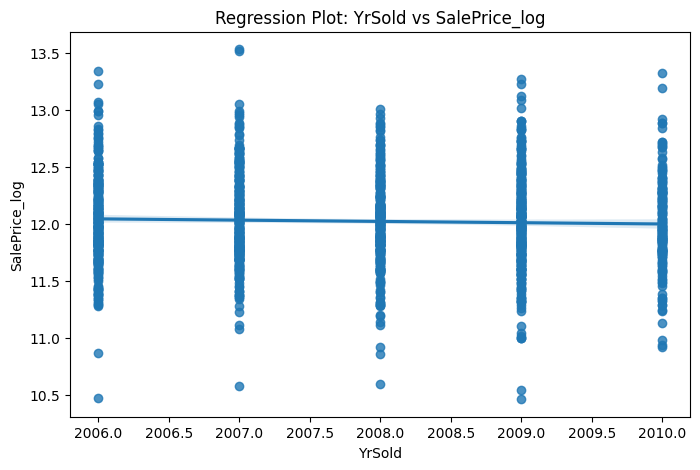

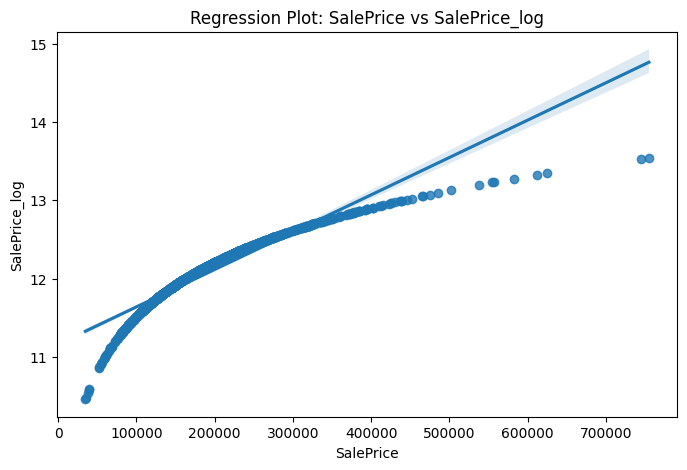

In [55]:
# Create regression plots for all numeric columns except 'SalePrice'
for col in continuous_data.columns:
    if col != 'SalePrice_log':  # Avoid plotting SalePrice against itself
        plt.figure(figsize=(8, 5))
        sns.regplot(x=continuous_data[col], y=continuous_data['SalePrice_log'])
        plt.xlabel(col)
        plt.ylabel('SalePrice_log')
        plt.title(f'Regression Plot: {col} vs SalePrice_log')
        plt.show()

## Categorical data

In [57]:
# Select object (categorical) columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Add 'SalesPrice' to the selected columns
categorical_columns.append('SalePrice')

# Create categorical_data DataFrame
categorical_data = df[categorical_columns]

# Display the first 5 rows of the categorical data
categorical_data.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,SalePrice
0,RL,Pave,Not Applicable,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,208500
1,RL,Pave,Not Applicable,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,181500
2,RL,Pave,Not Applicable,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,223500
3,RL,Pave,Not Applicable,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Unf,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Abnorml,140000
4,RL,Pave,Not Applicable,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,250000


### Distribution

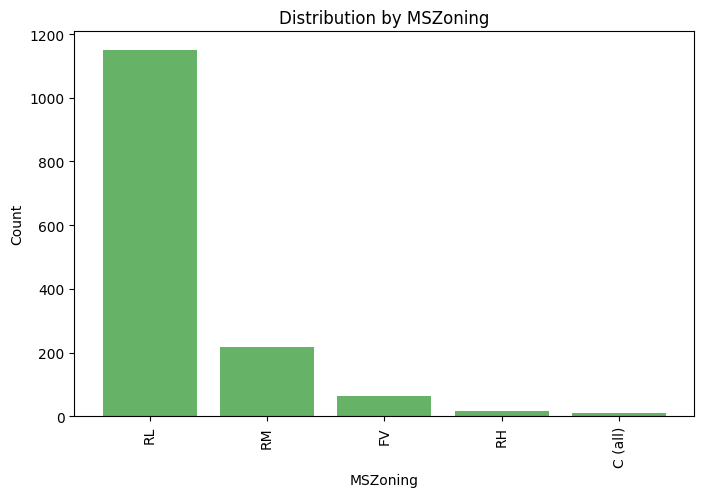

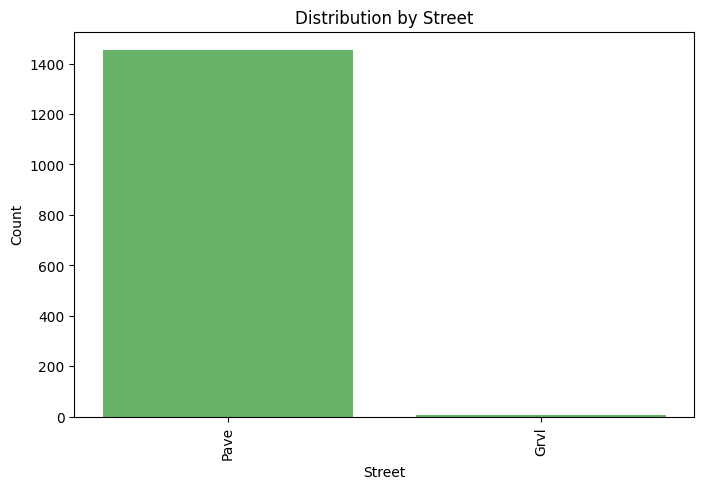

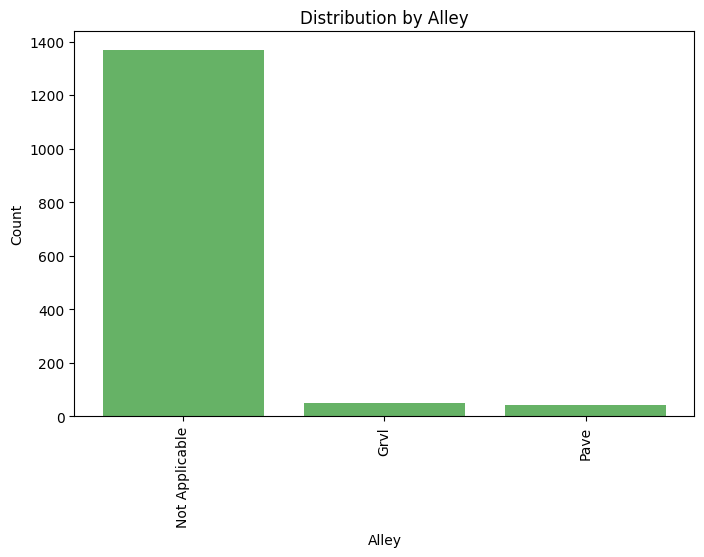

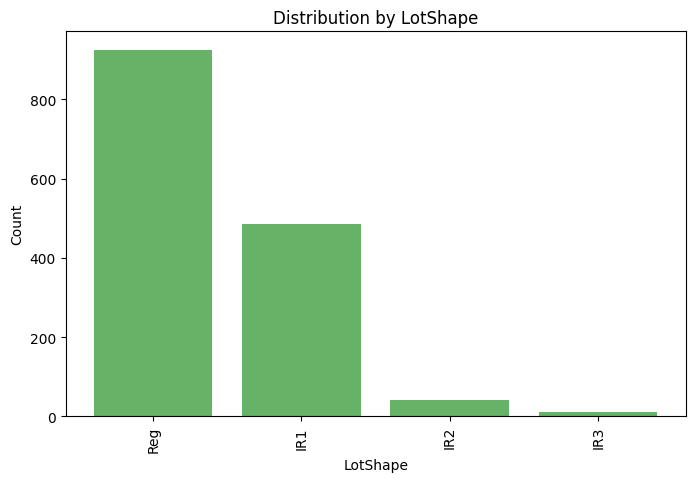

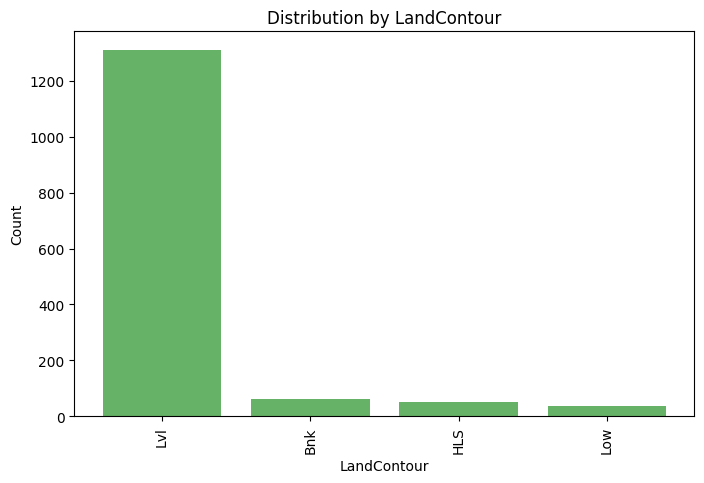

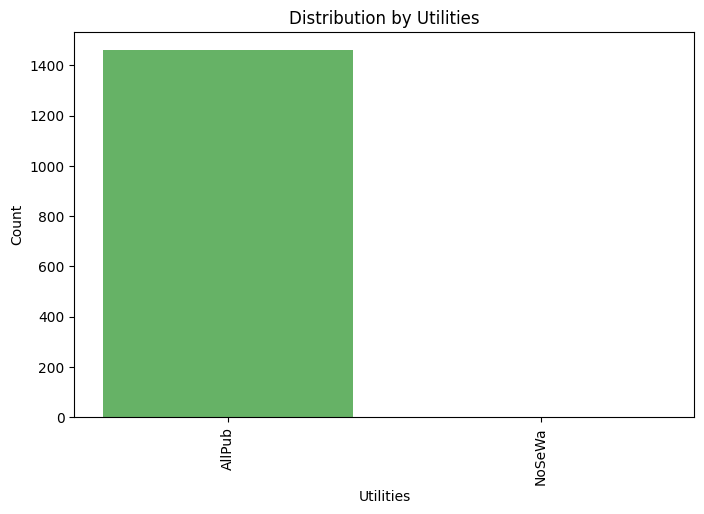

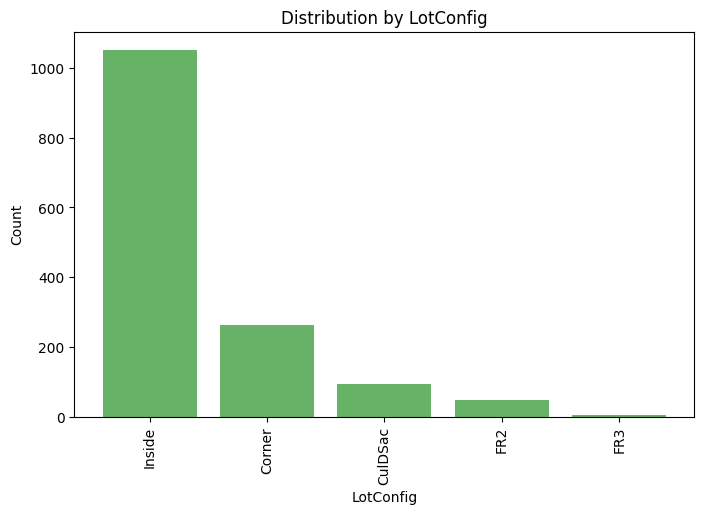

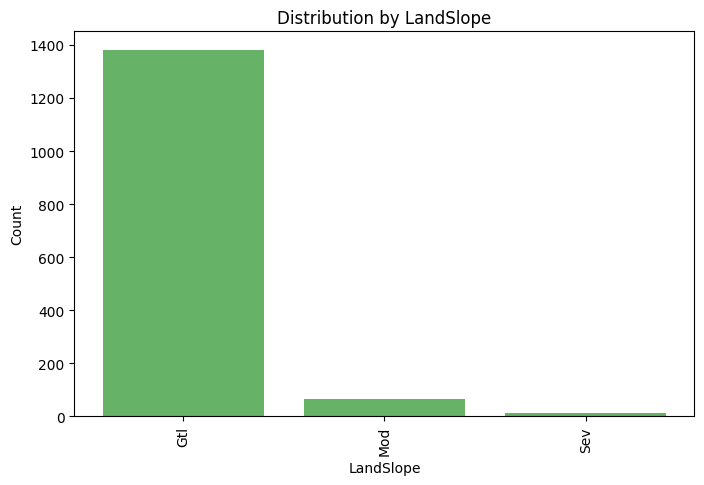

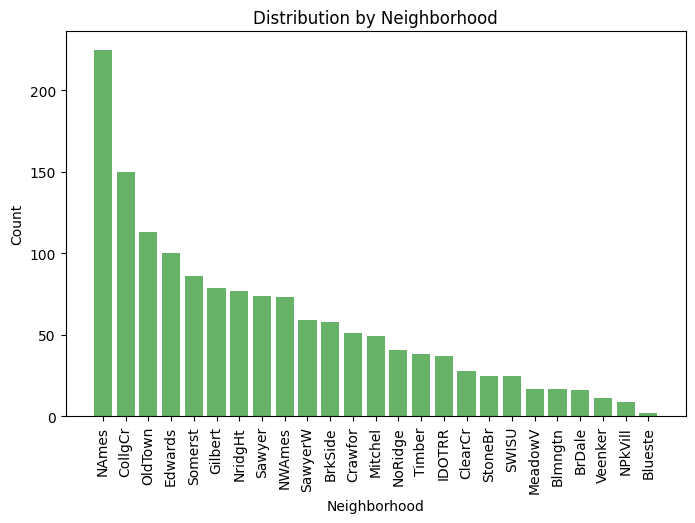

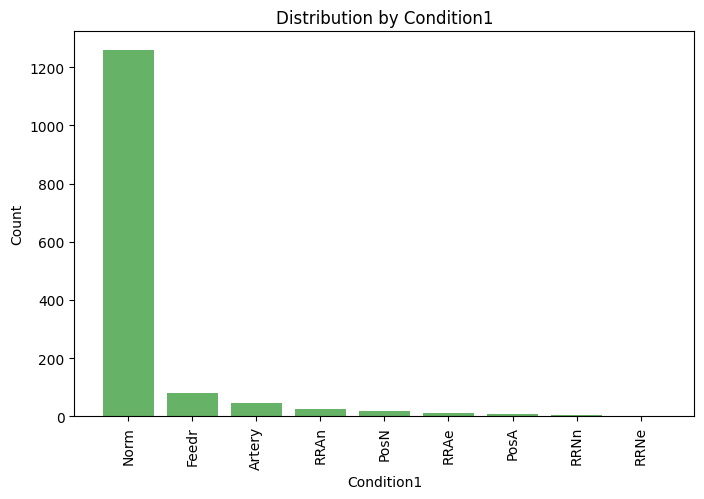

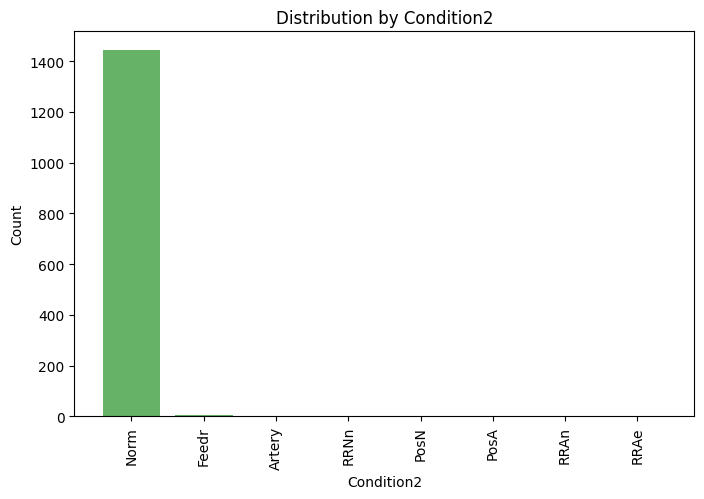

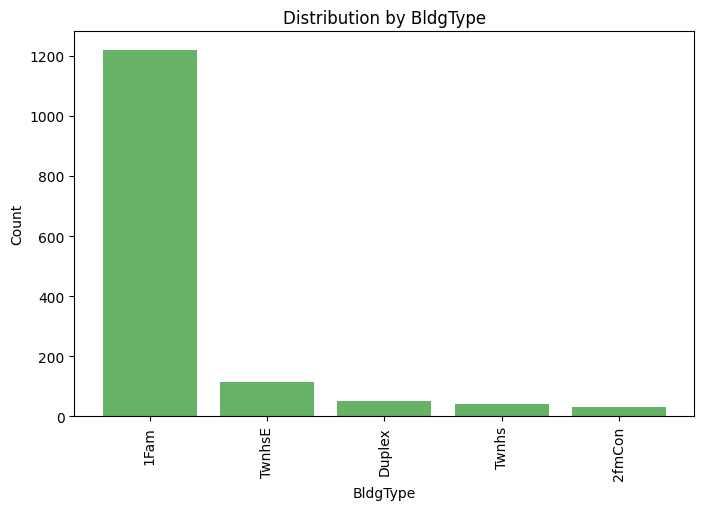

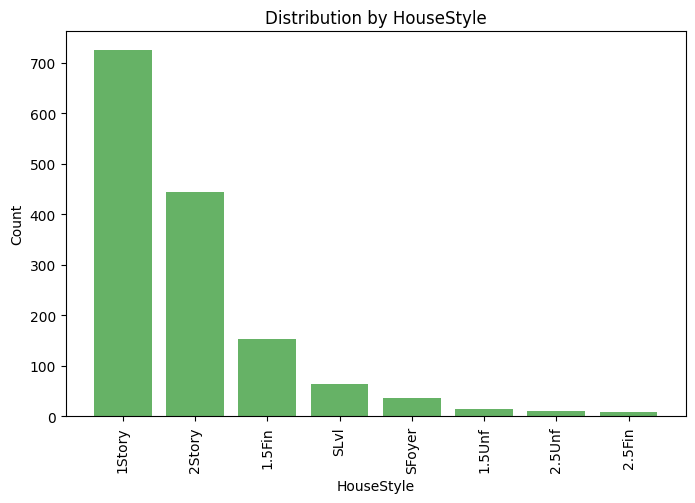

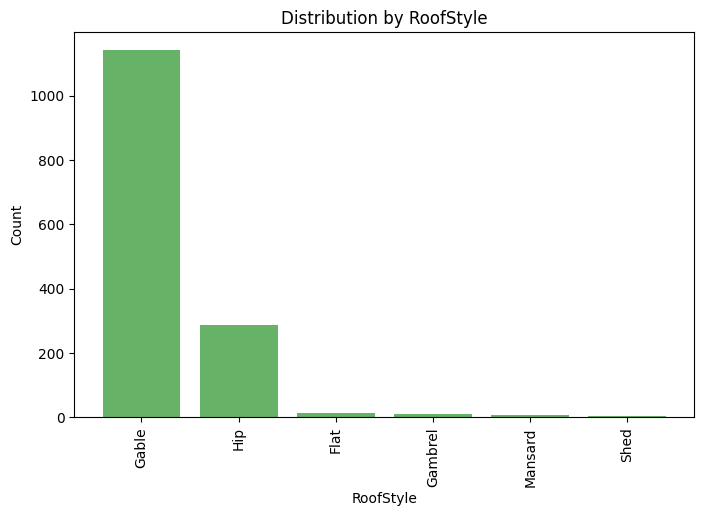

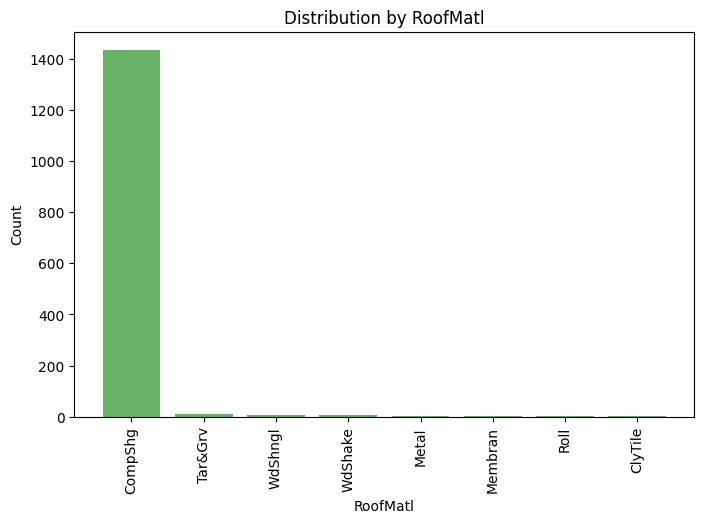

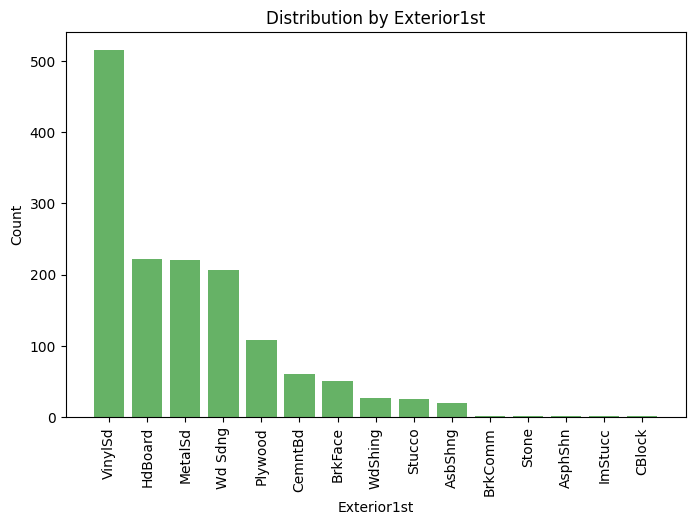

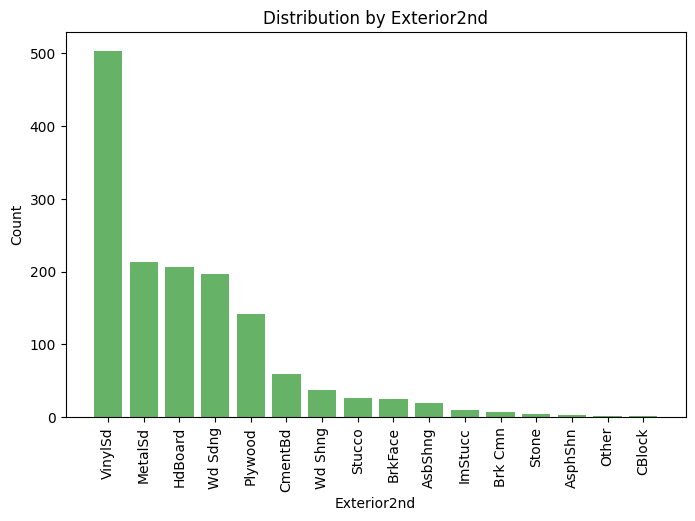

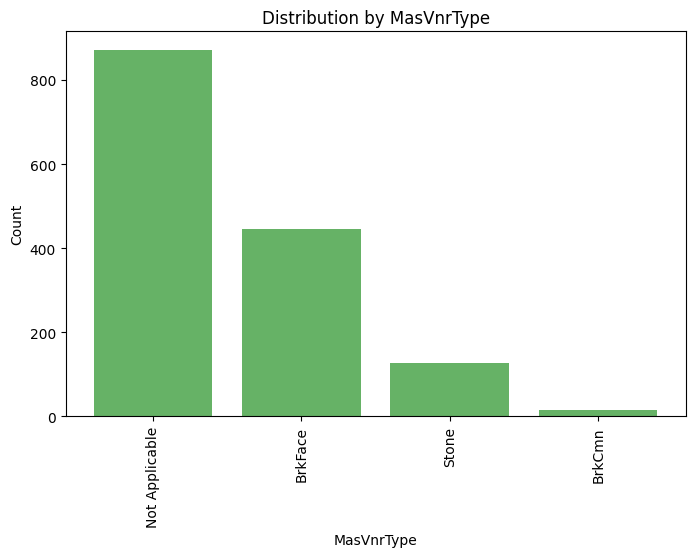

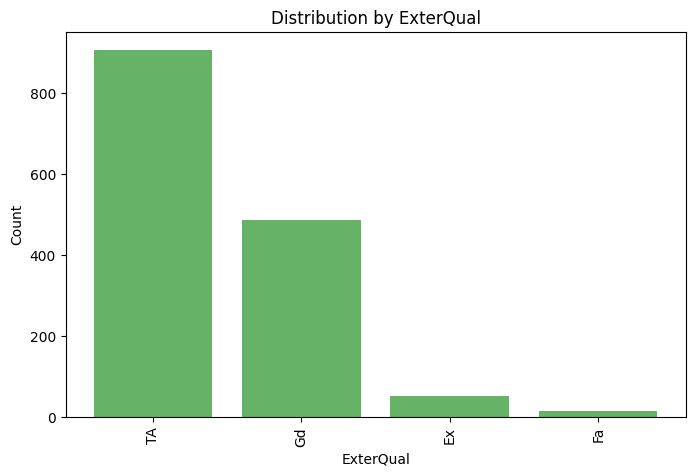

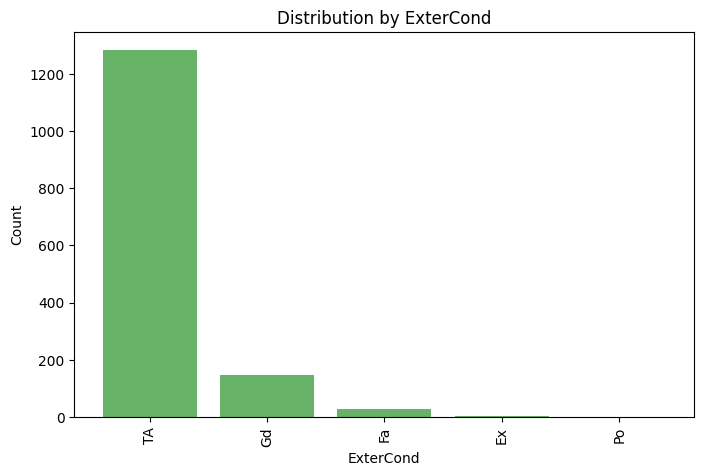

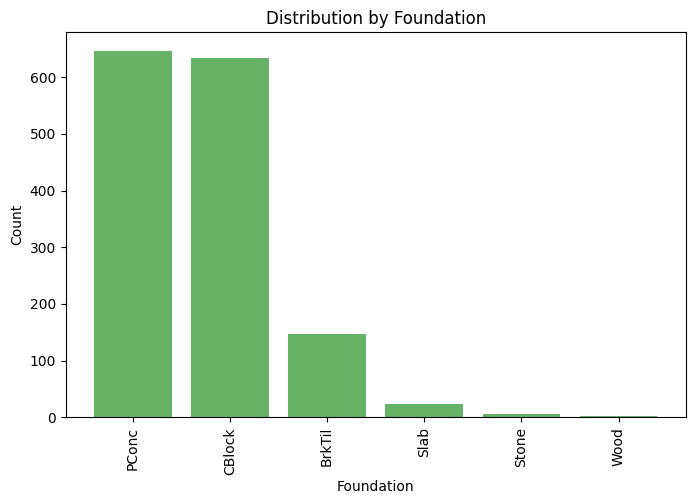

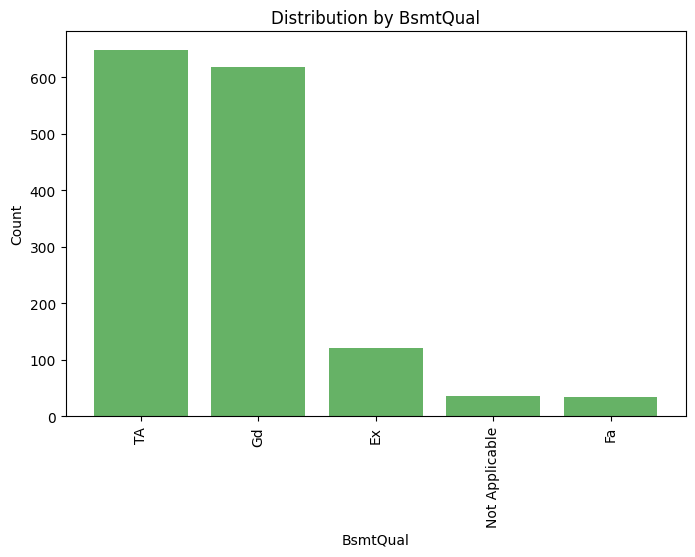

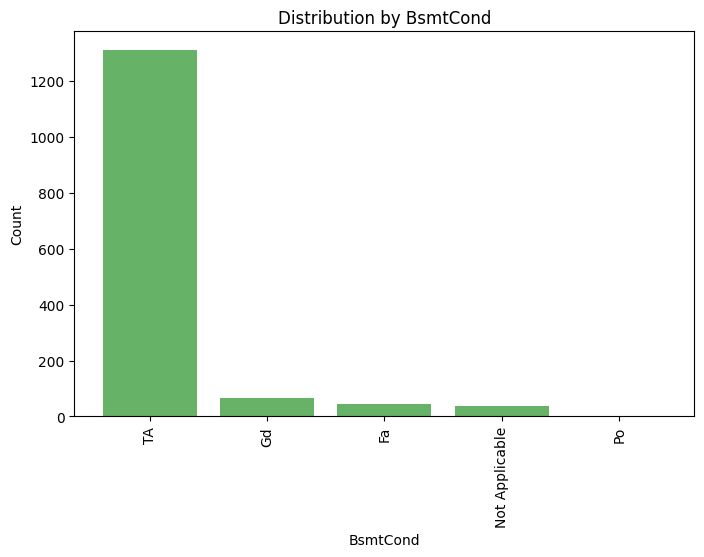

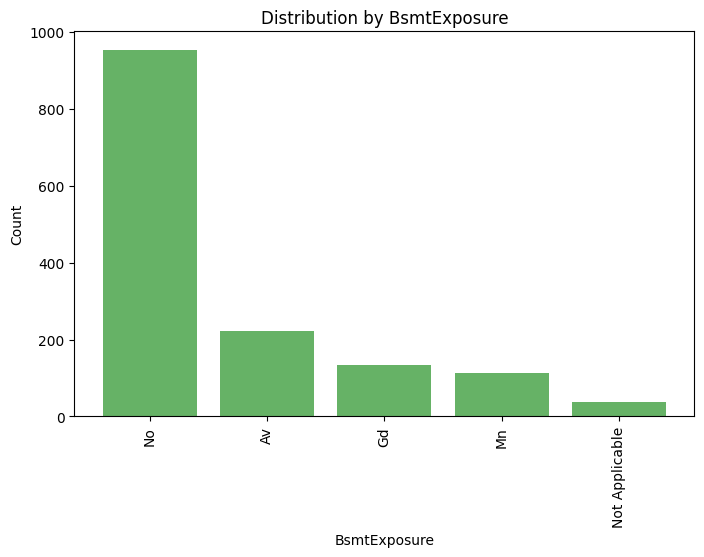

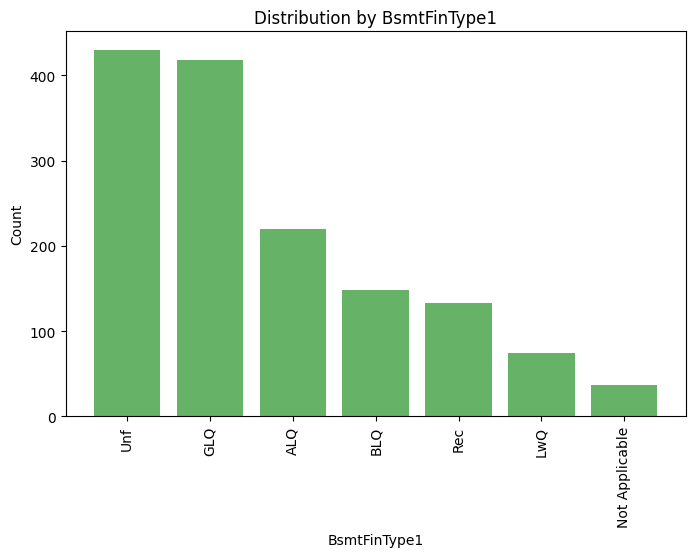

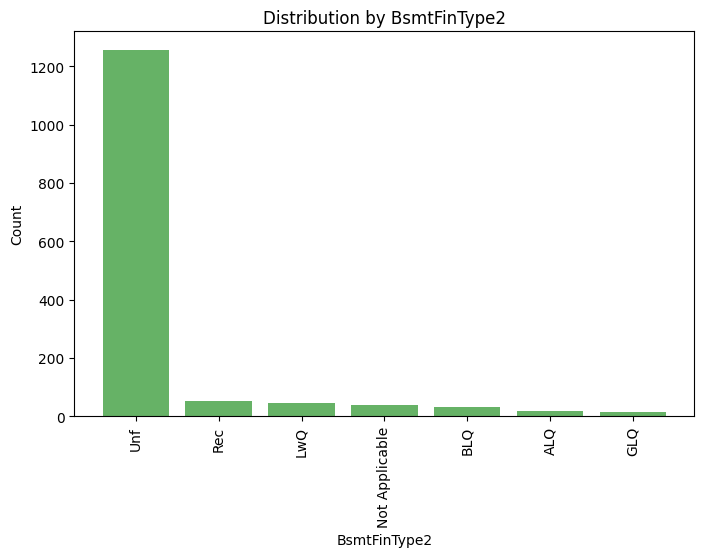

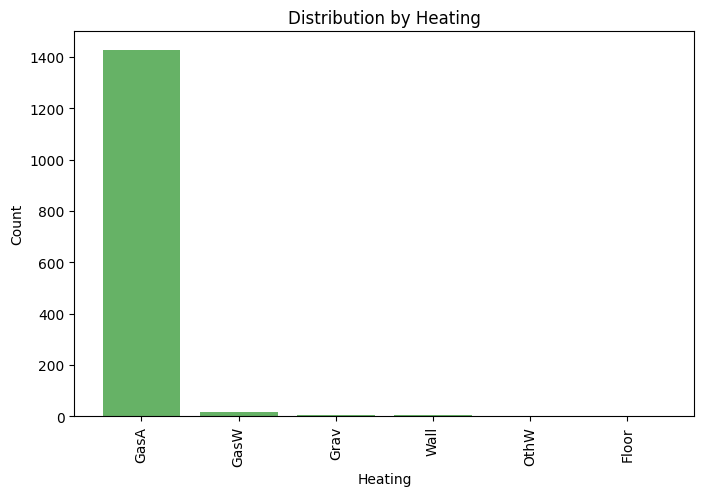

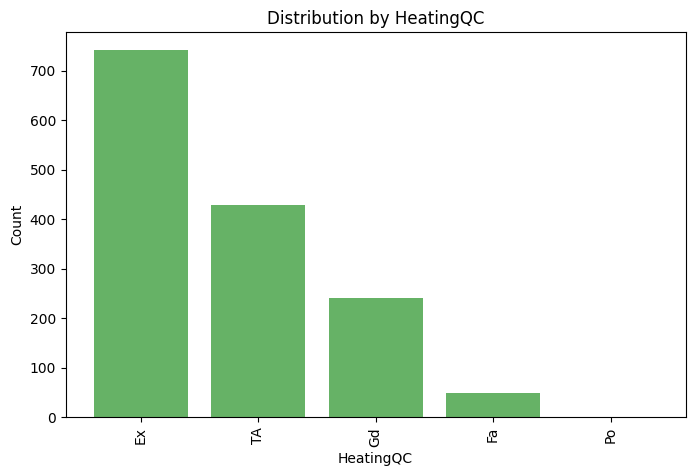

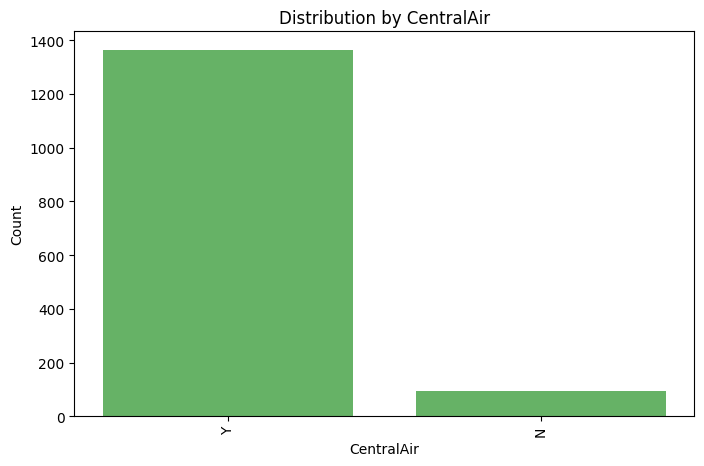

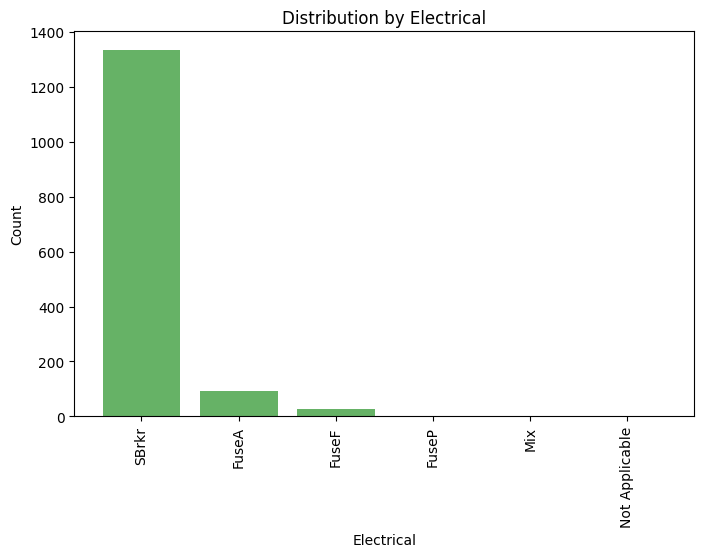

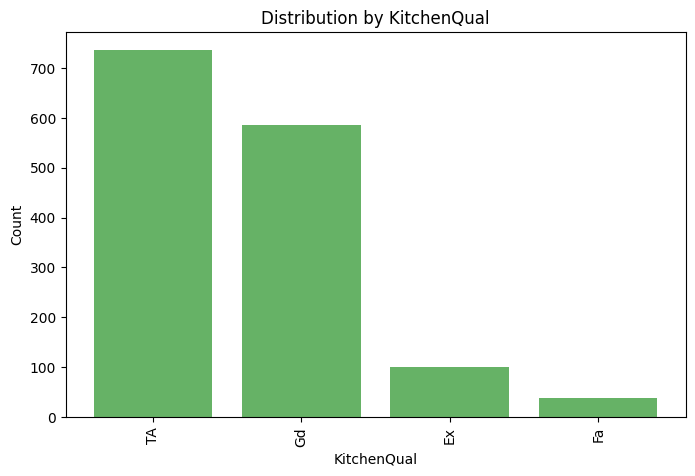

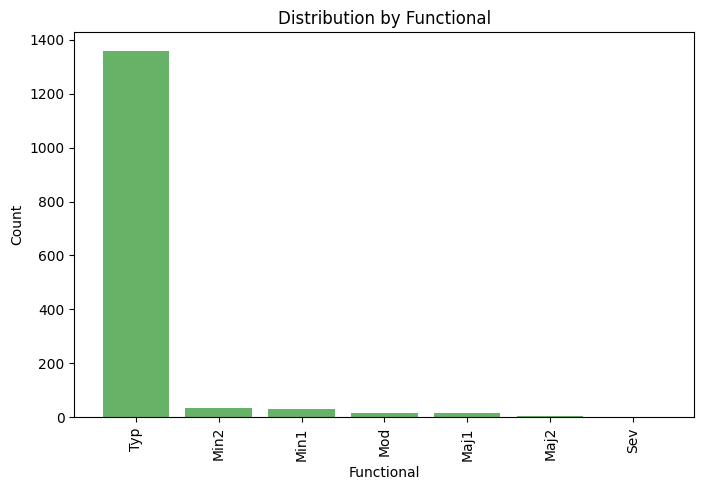

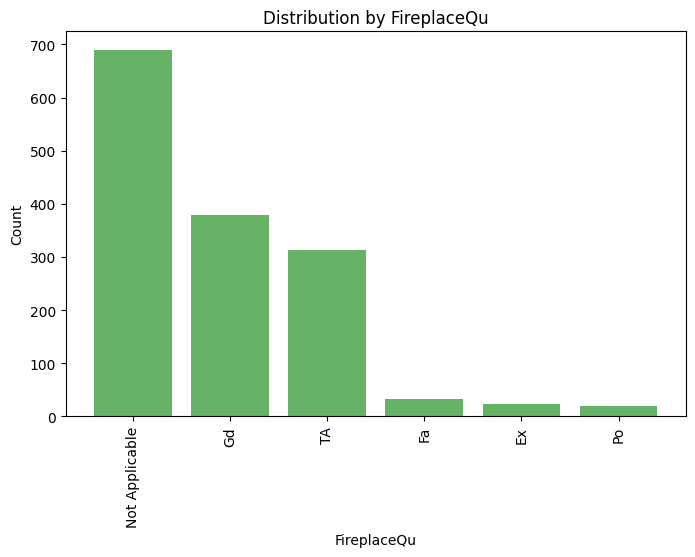

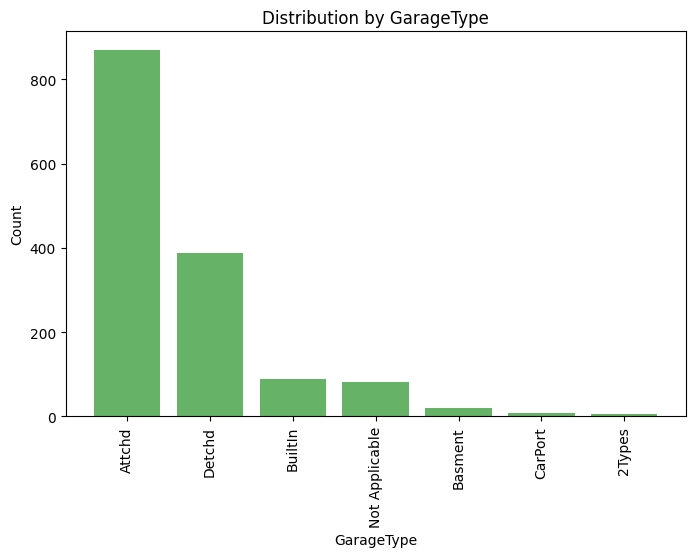

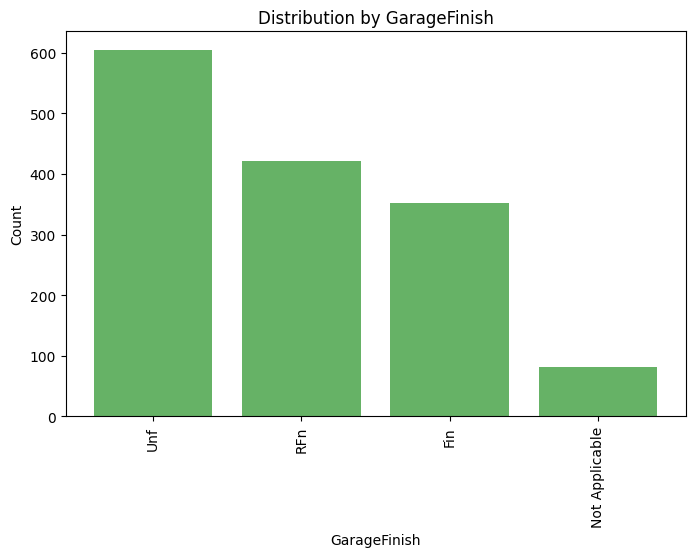

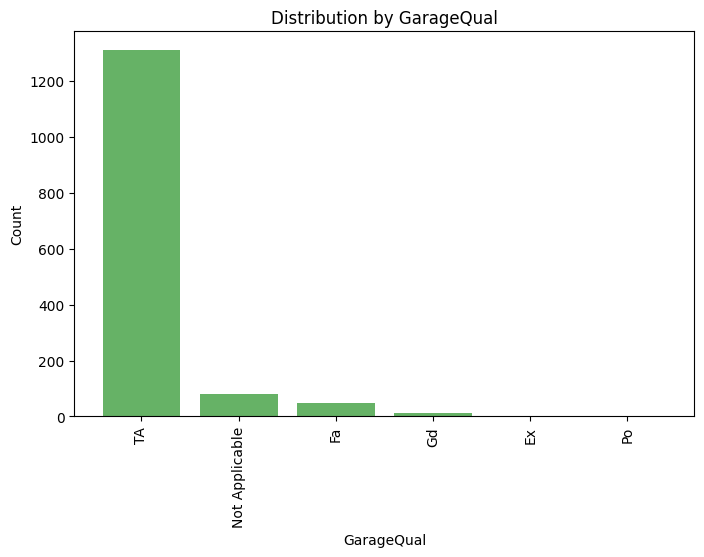

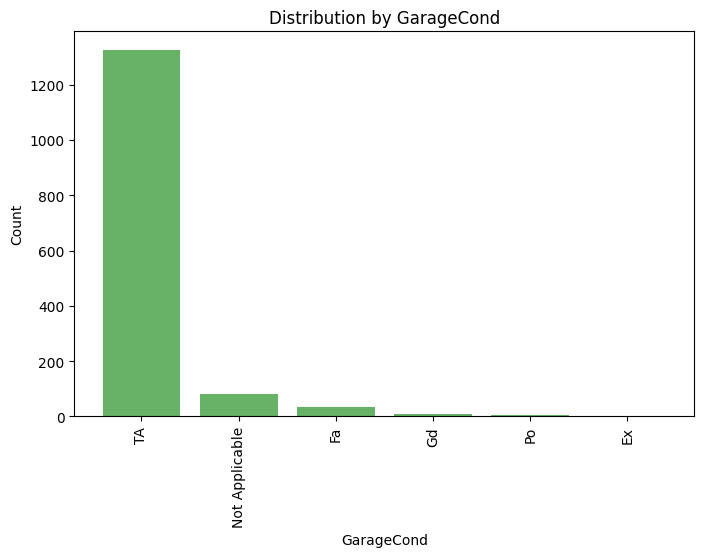

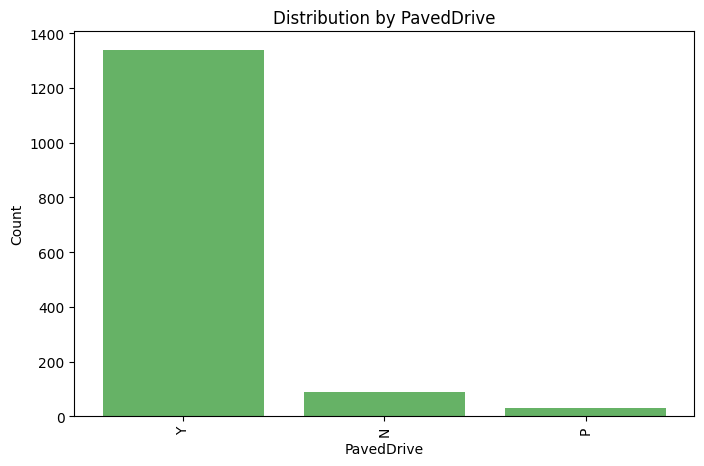

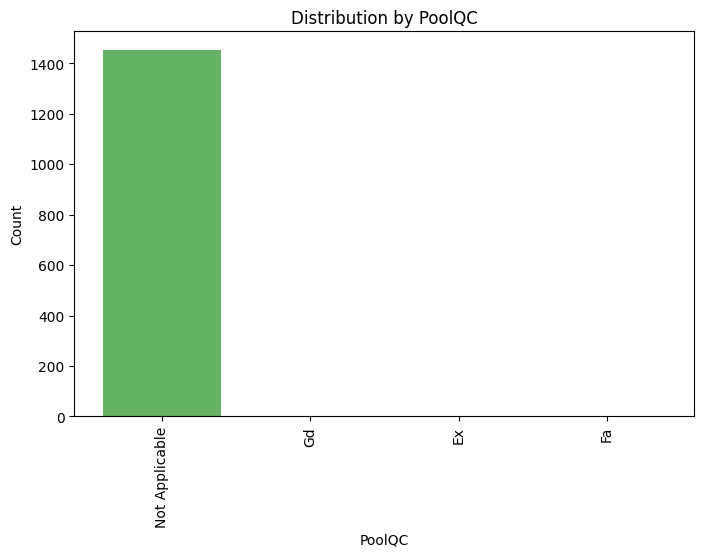

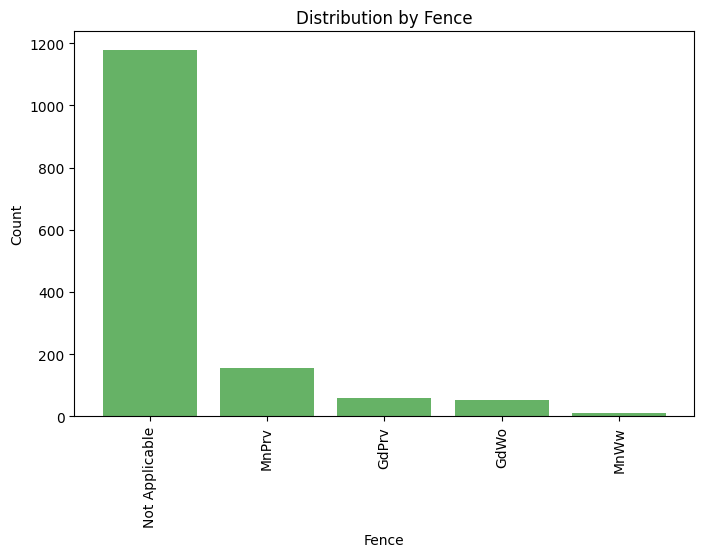

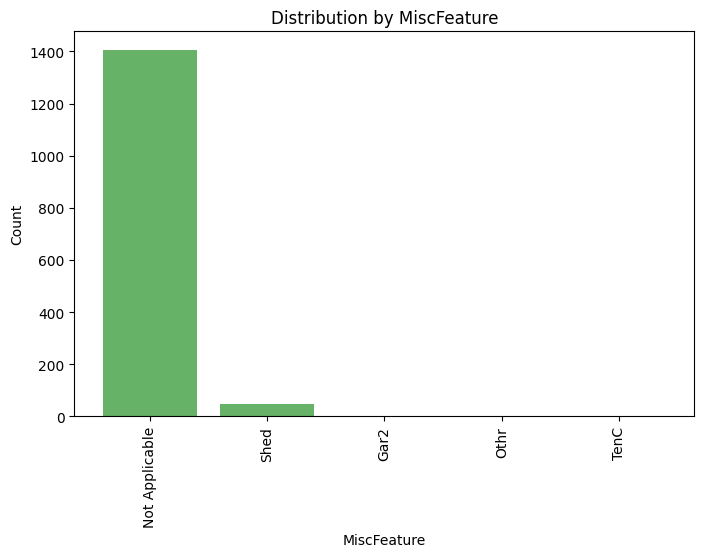

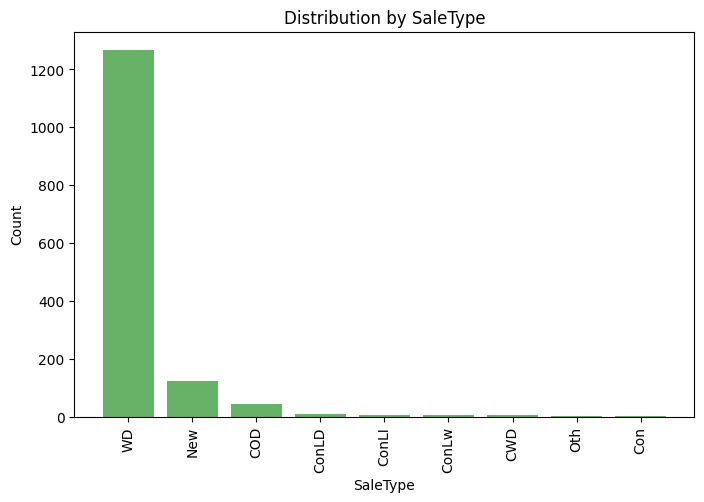

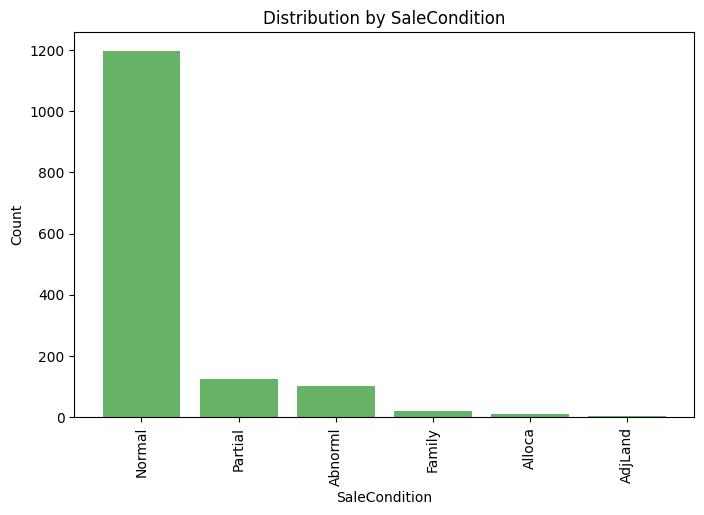

In [58]:
# Creating plots for each categorical variable
for col in categorical_data.columns:
    if col != 'SalePrice':  # Skip if the column is 'SalePrice'
        category_counts = categorical_data[col].value_counts()

        fig, ax1 = plt.subplots(figsize=(8, 5))

        # Bar plot for category counts
        ax1.bar(category_counts.index, category_counts.values, alpha=0.6, color='green', label='Count')
        ax1.set_ylabel('Count', color='black')
        ax1.set_xlabel(col)

        # Rotate x-axis labels to 90 degrees
        plt.xticks(rotation=90)
        plt.title(f'Distribution by {col}')
        plt.show()


### Median Value per category

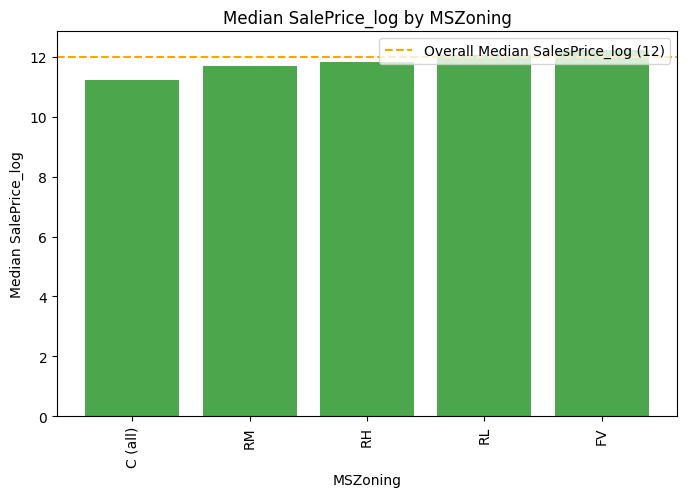

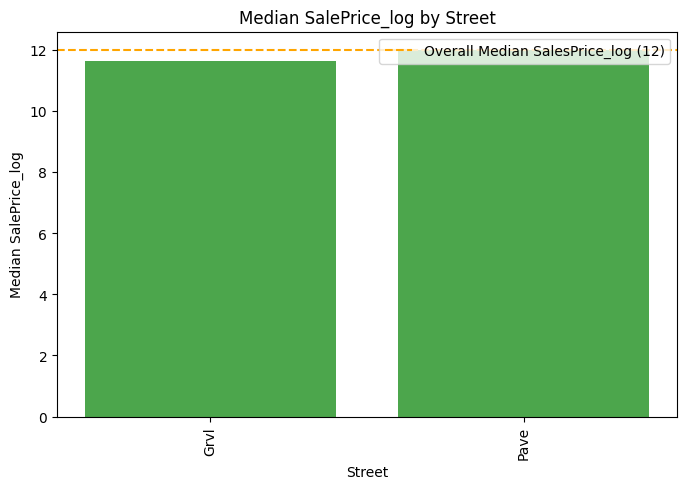

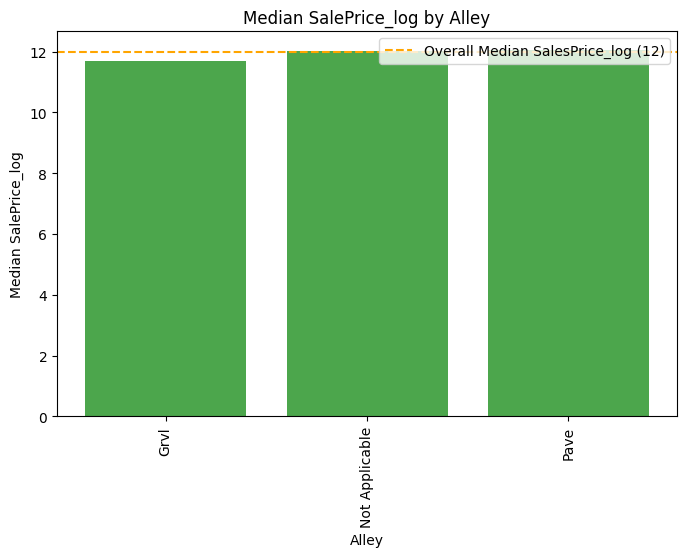

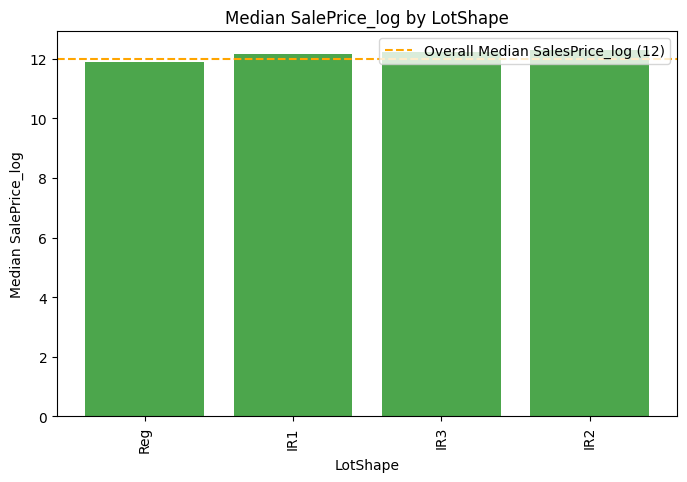

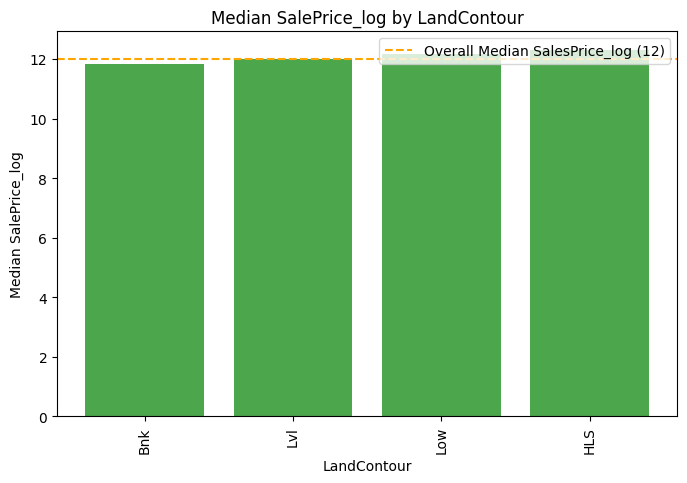

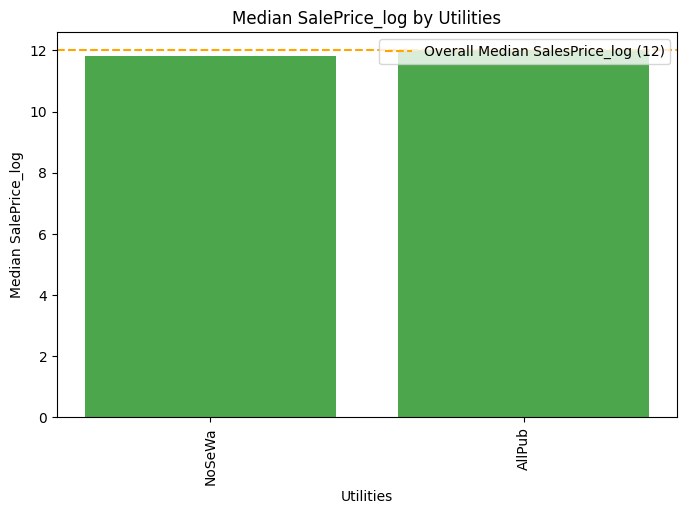

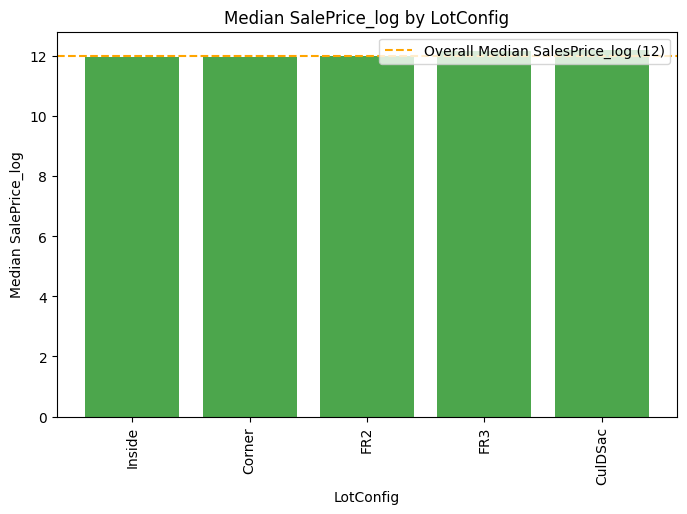

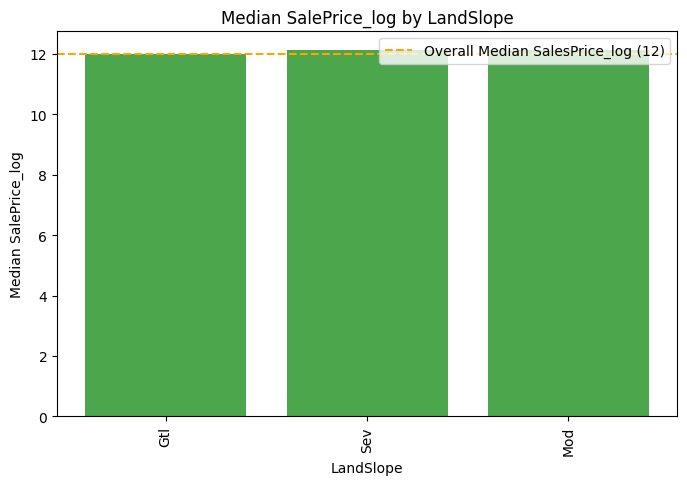

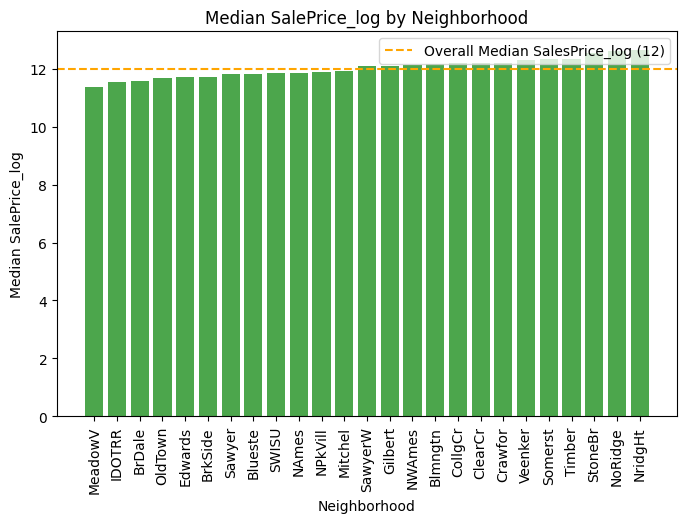

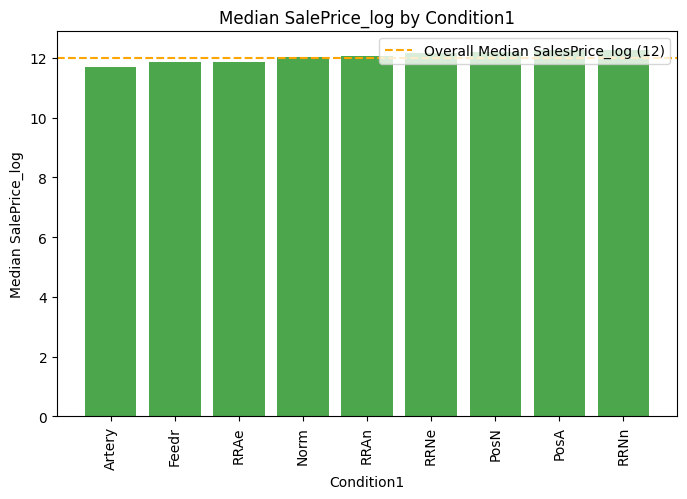

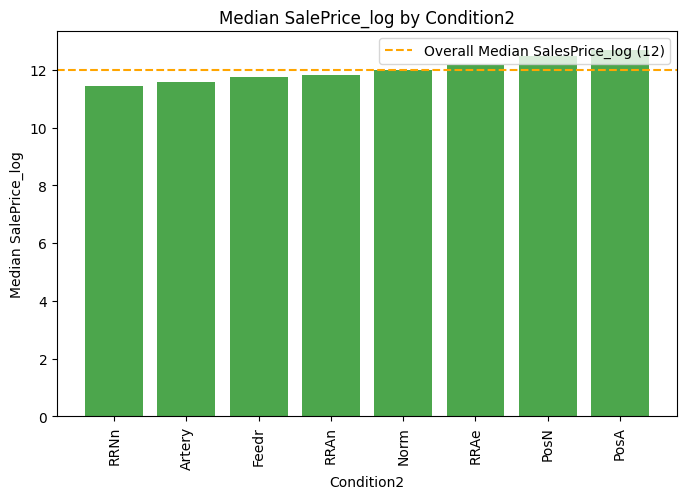

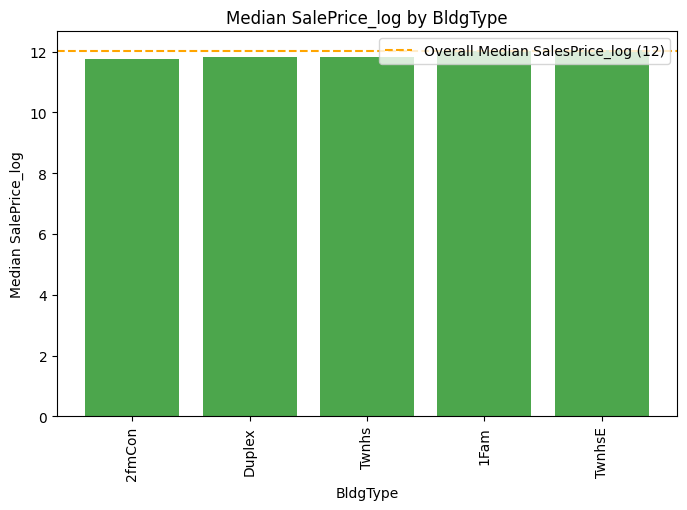

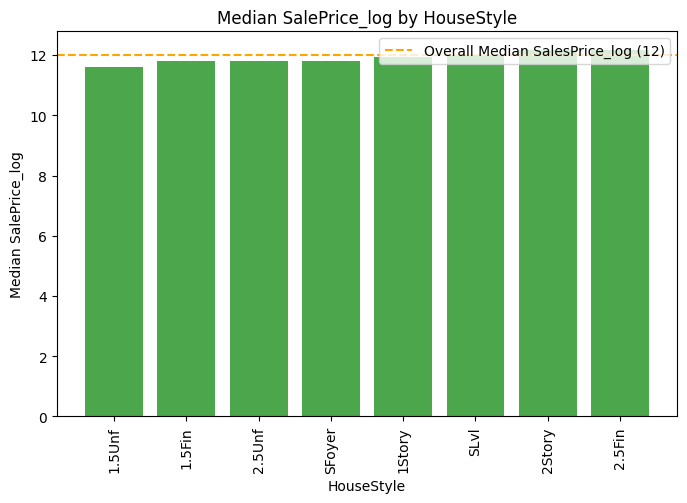

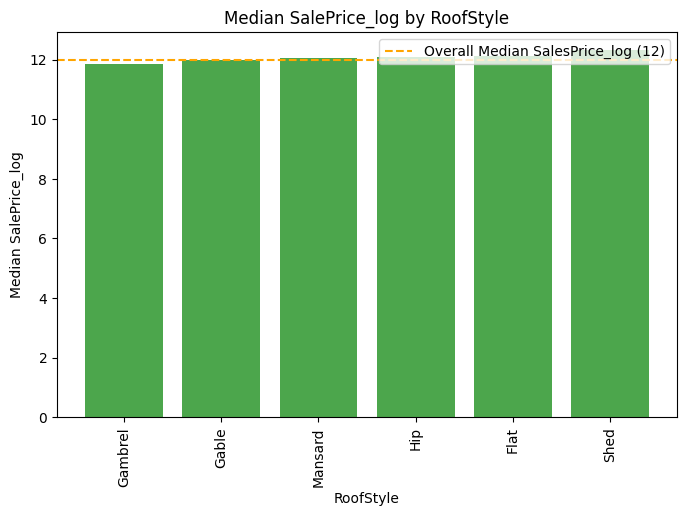

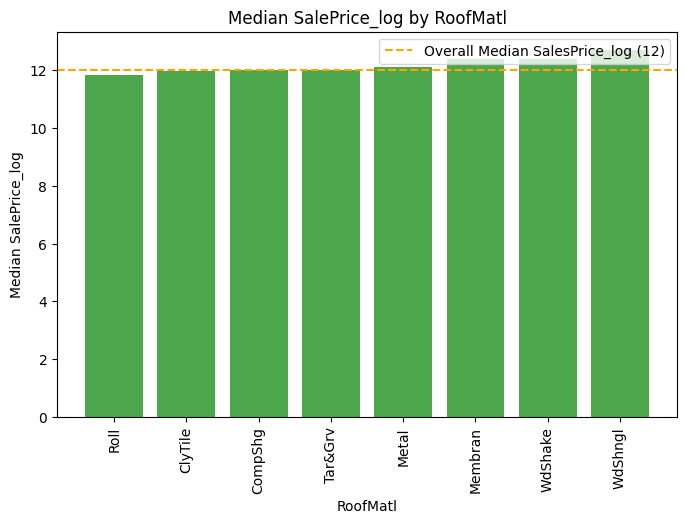

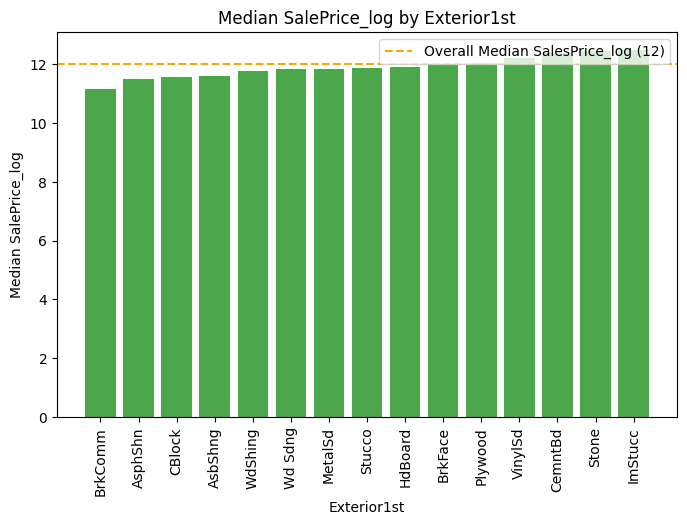

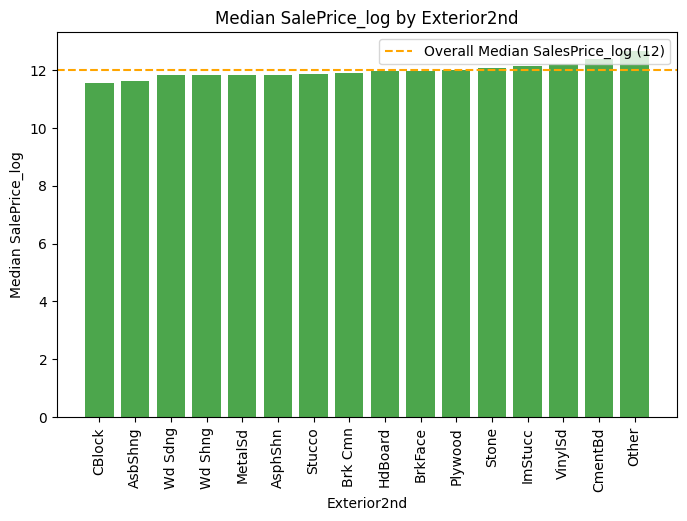

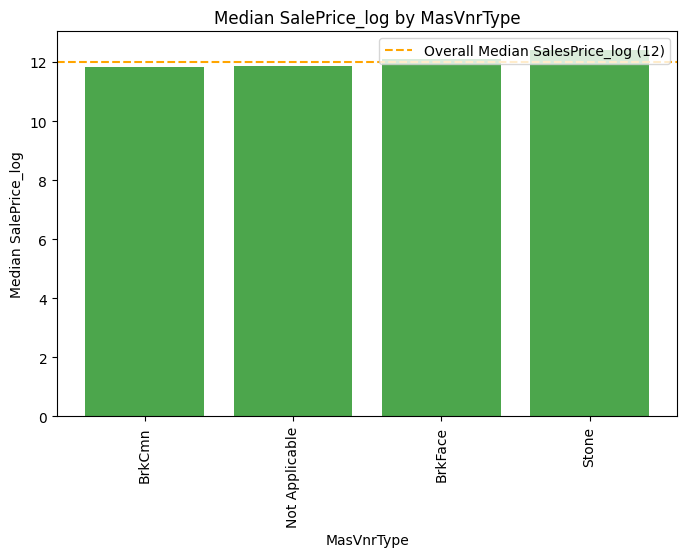

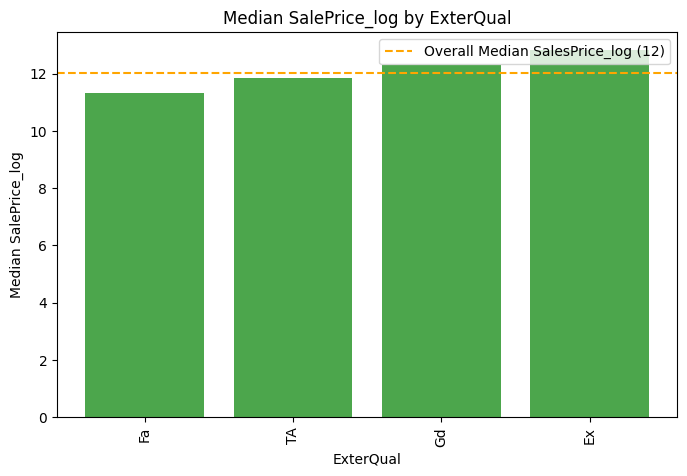

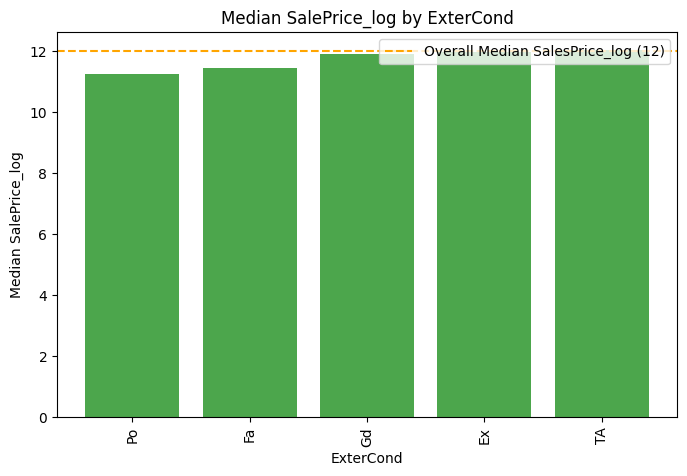

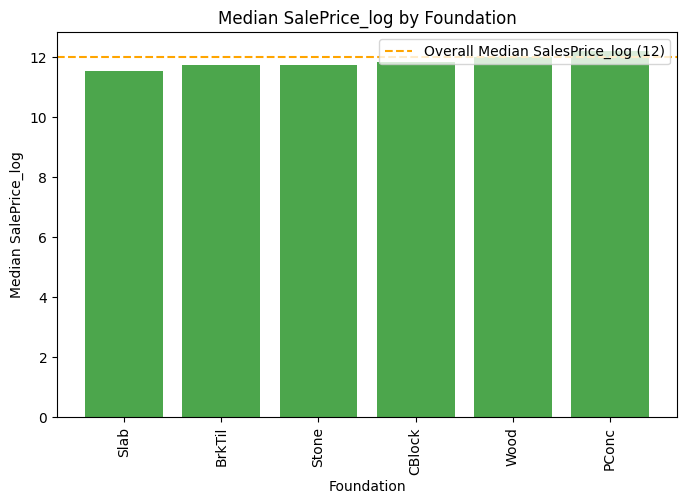

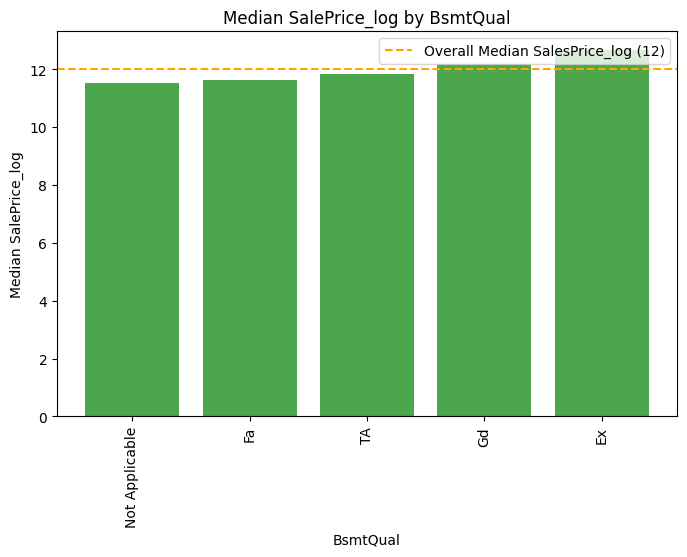

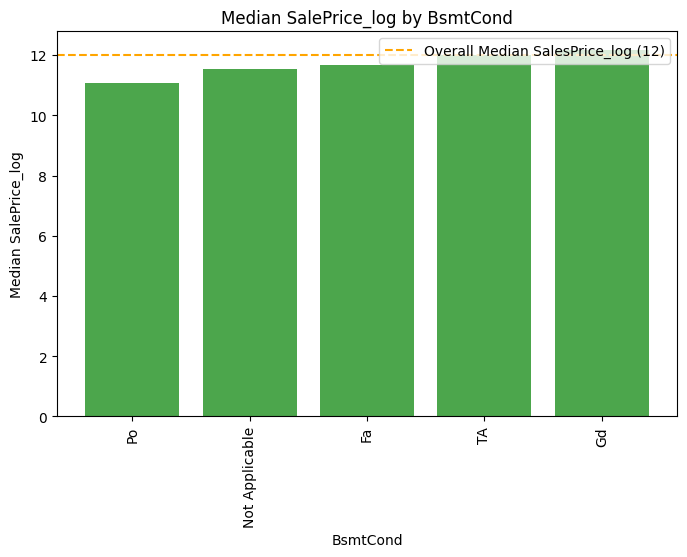

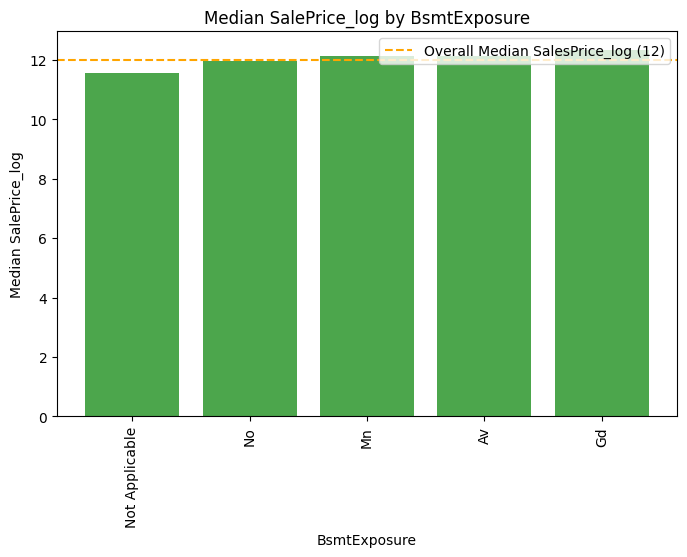

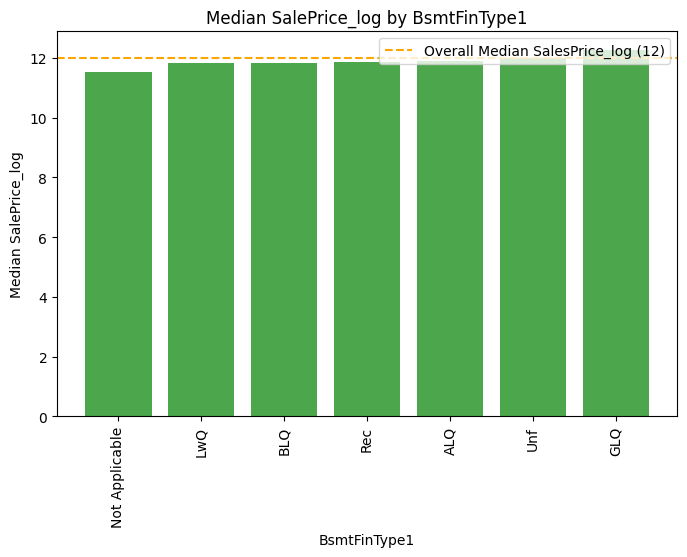

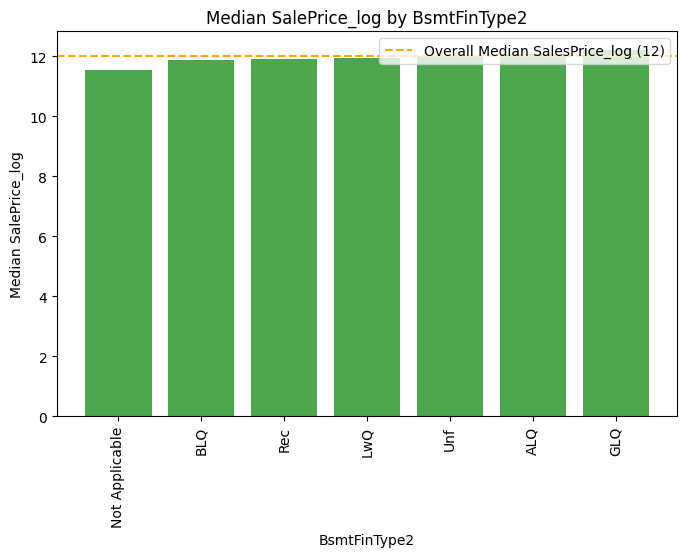

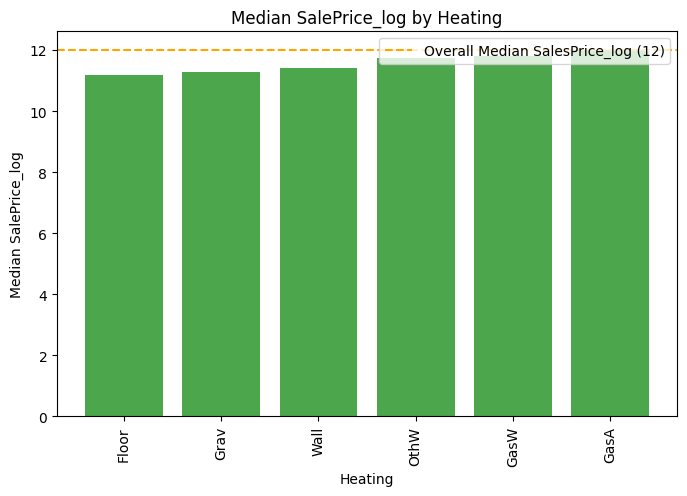

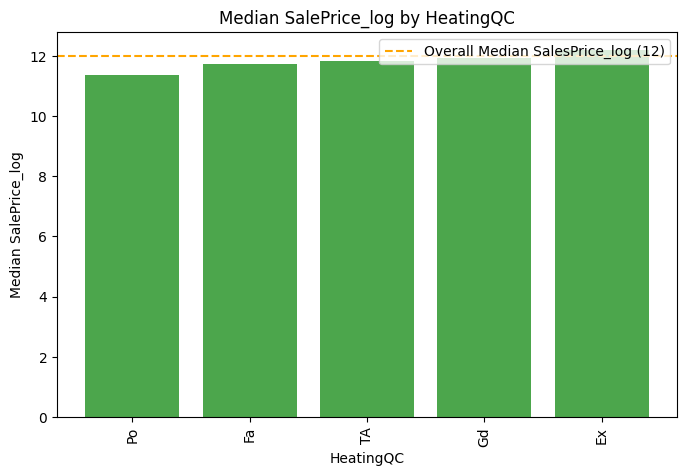

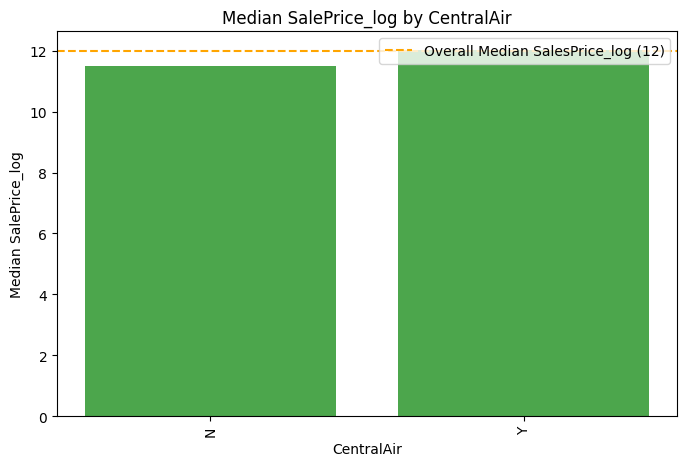

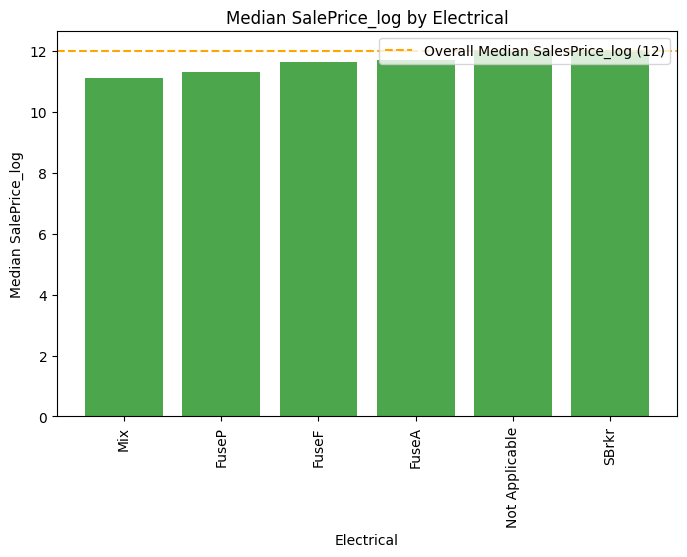

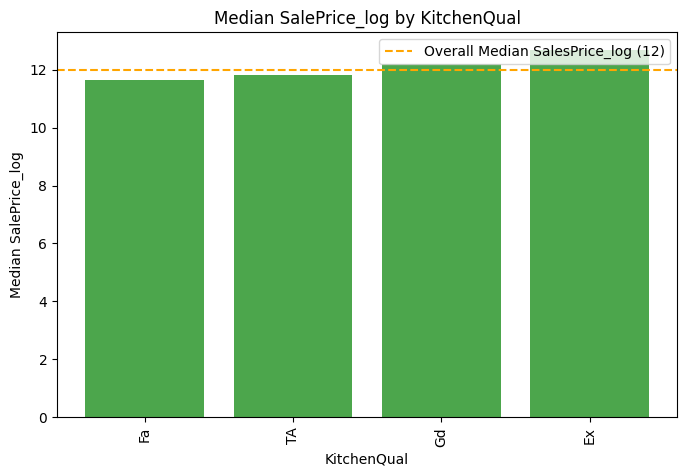

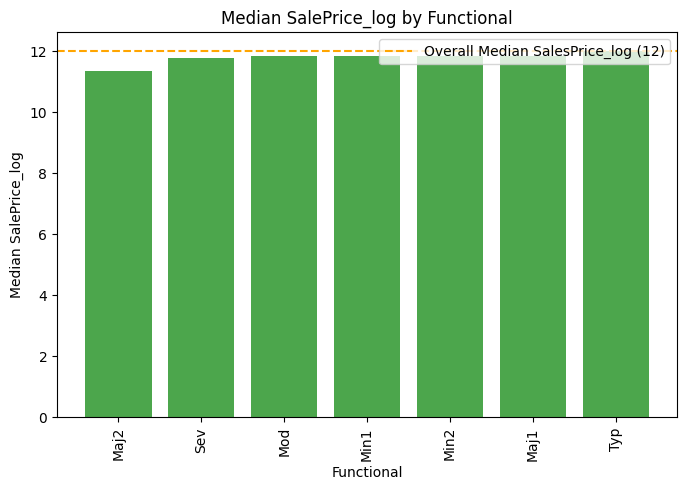

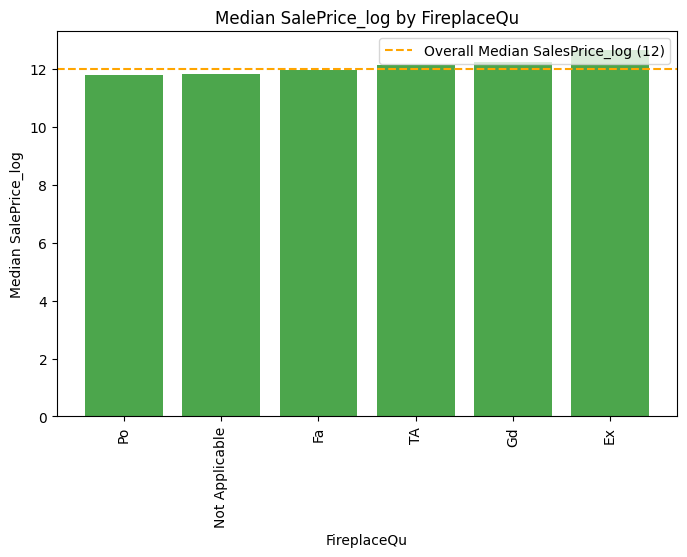

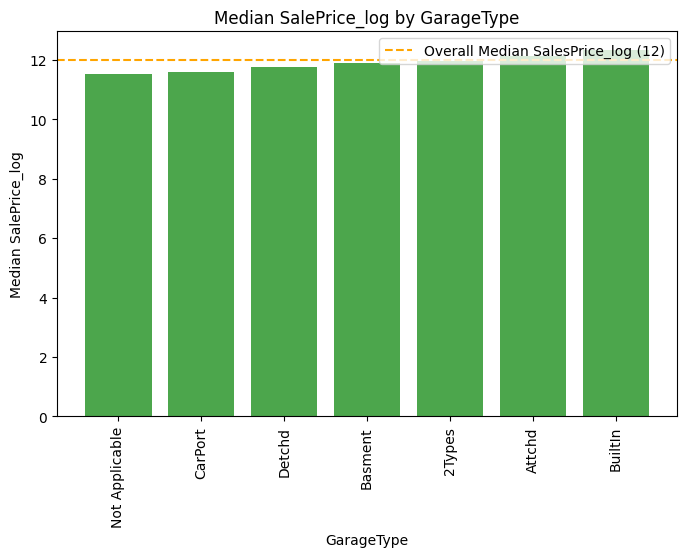

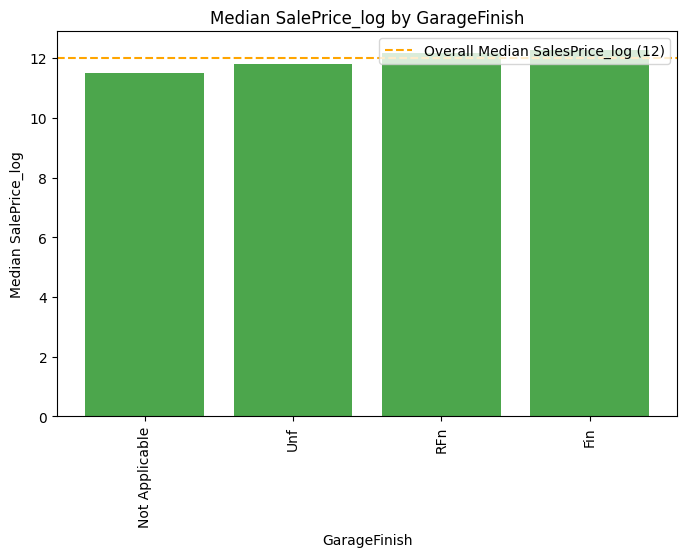

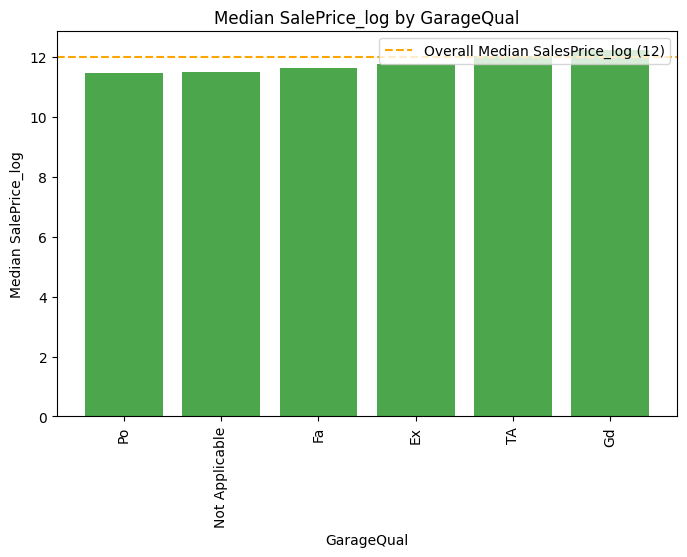

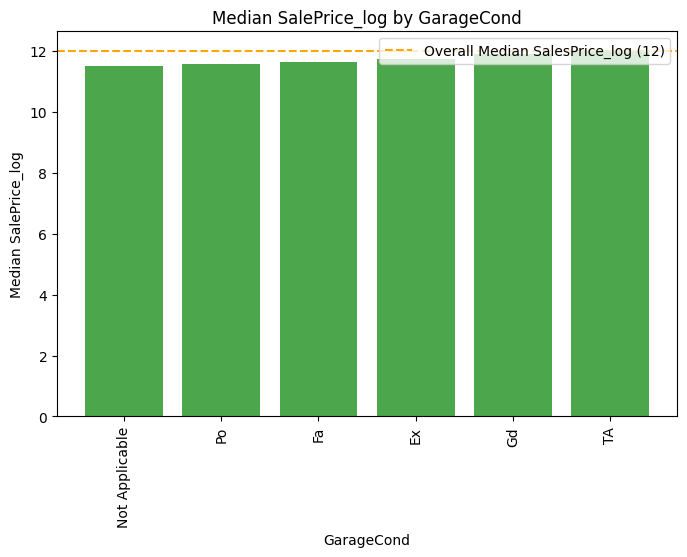

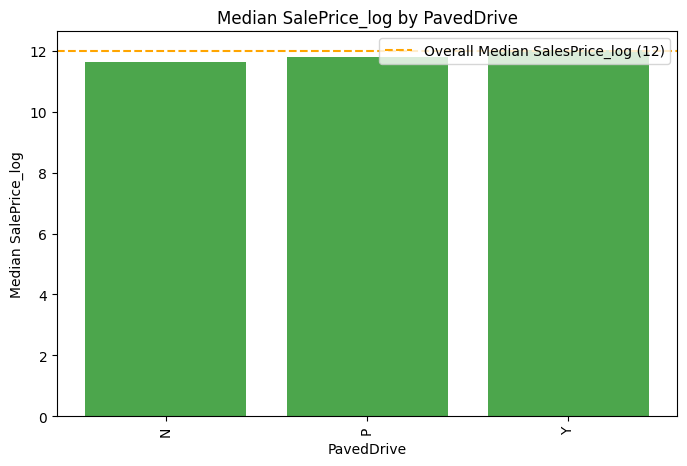

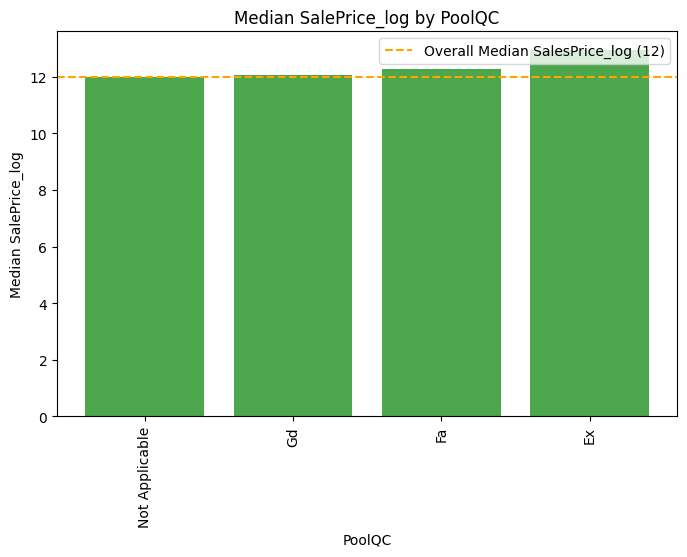

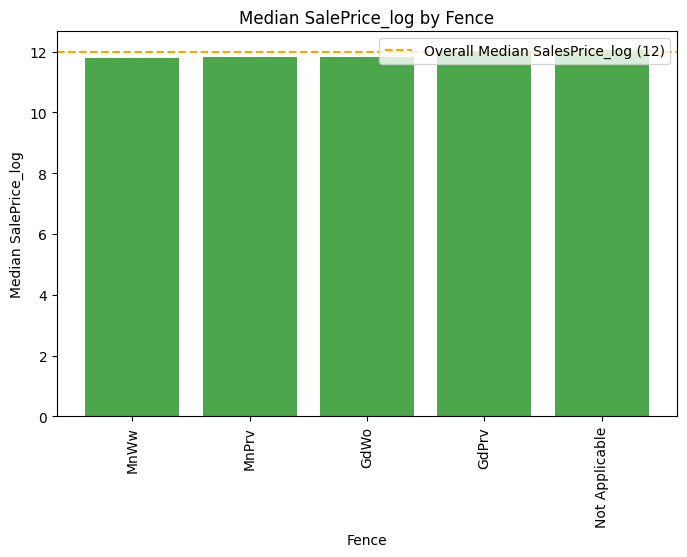

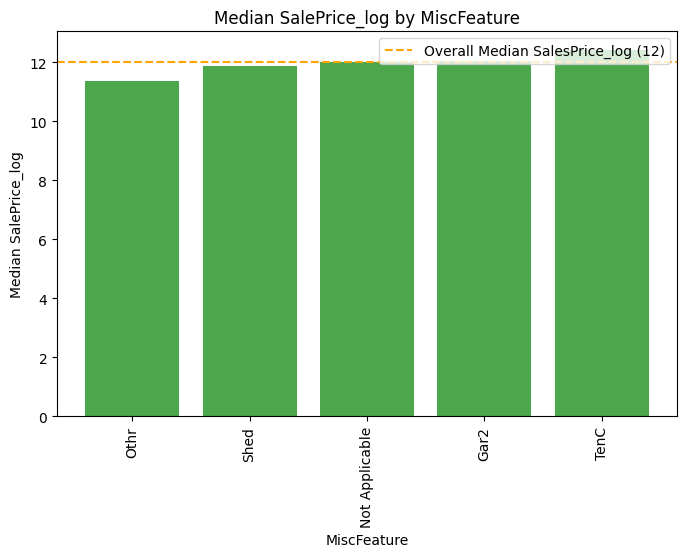

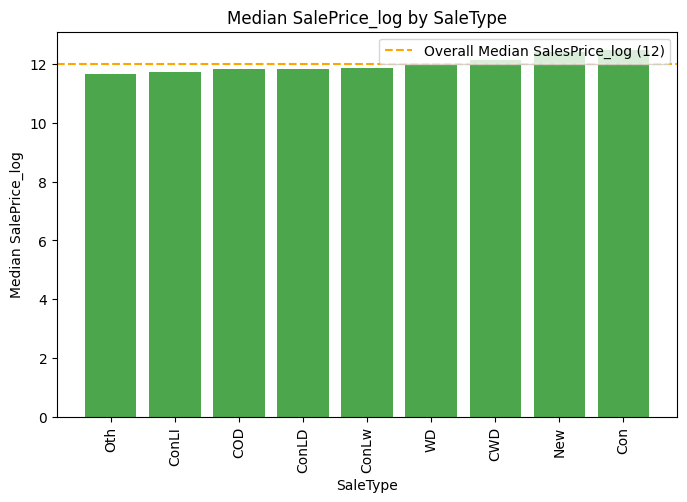

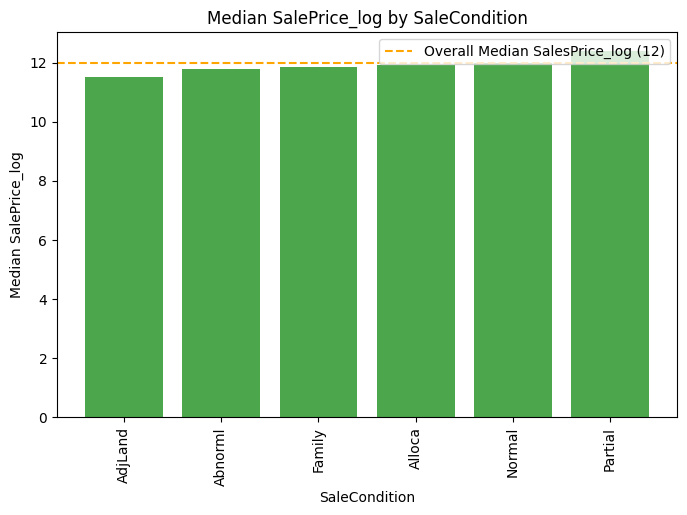

In [59]:
# Select categorical columns (excluding SalePrice_log)
categorical_data = df.select_dtypes(include=['object'])

# Compute overall median of SalePrice_log
overall_median = df['SalePrice_log'].median()

# Creating plots for each categorical variable (EXCLUDING SalePrice_log)
for col in categorical_data.columns:
    # Calculate median SalePrice_log for each category
    category_medians = df.groupby(col)['SalePrice_log'].median().sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))

    # Bar plot for median SalePrice_log per category (EXCLUDE from legend)
    bars = ax.bar(category_medians.index, category_medians.values, color='green', alpha=0.7)

    ax.set_ylabel('Median SalePrice_log', color='black')
    ax.set_xlabel(col)
    
    # Rotate x-axis labels to 90 degrees for readability
    plt.xticks(rotation=90)

    # Add an overall median line (WITH legend)
    median_line = ax.axhline(y=overall_median, color='orange', linestyle='--', label=f'Overall Median SalesPrice_log ({overall_median:,.0f})')

    # Manually set legend, excluding bar plot
    ax.legend(handles=[median_line], loc='upper right')

    # Add title
    plt.title(f'Median SalePrice_log by {col}')

    plt.show()


#### Notes on the distribution
Based on the preliminary view the following variables are highly skewed and should be removed or grouped:

**Grouped**

Neighborhood (5 x median SalePrice), Roofstyle(Gable, Hip), RoofMatl (CompShg), ExterCond (TA, Gd + EX) BsmtCond (TA & Gd), BsmtFinType2 (Unf + ALQ + GLQ), Heating (GasA), Electrical (SBrkr) Functional (Typ), GarageQual (TA + Gd), GarageCond (TA + Gd)

**Removed**

Street, Alley, Utilities, Condition2, PoolQC, MiscFeature

In [60]:
# Export the reviewed data with the excluded columns to create a new csv
# Create a list of columns to exclude
columns_to_exclude = ['Street', 'Alley', 'Utilities', 'Condition2', 'PoolQC', 'MiscFeature']

# Drop the columns from the data
df = df.drop(columns_to_exclude, axis=1)

# Export the data to a new csv file
df.to_csv('outputs/train_cleaned_trimmed.csv', index=False)